 Script to test the Fama French asset pricing model from 1970-2024 (actually 1972)
 What this fisrt code block does:
- connecting to google drive, than importing the relevant modules / libraries
- importing the CSPR data for 1970-2024, which includes (INSERT CHARACTERISTICS OF THE DATASET)
- open the dataset and select only relevant variables through SQL query in python
- transform columns that have numbers to actual numbers and date columns in data format Ymd, also returns * 100
- select only the 'common shares', which are code 10, 11 (shrcd) because CRSP includes also other kinds of shares
- calculate the market cap of each stock and drop missing / nan values
- classify each stock with each exchange (31 or 1 = NYSE, 32 or 2 = AMEX, 33 or 3 = NASDAQ), and including only those in the database
- separates stocks that had delisting and that didn't (delisting codes 551 to 574 or 500, 520, 580, 584). Assing the return to each category of stock, like if it was not delisted than it has its normal return 're
t', if it was delisted and had delisting return than that delisting return, if it was delisted but no data on delisting reutrn, it gets -30% as common in literature
- finally readjusting the index and dropping the columns we used so far but that will be useless


In [ ]:
### FIRST CODE BLOCK

### Connecting to google drive

from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)

!pip install pandasql
import os
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as sm
import numpy as np
from sqlite3 import connect
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize, ks_2samp
import seaborn as sns
import pandasql as ps

### importing relevant libraries and the CRSP dataset from 1970 to 2024
conn = connect(':memory:', timeout = 10)

filePath = '/content/gdrive/MyDrive/Final Thesis BSc BIEF Bocconi' # file path of the google drive where database are

file = filePath + '/CRSP1970To2024.csv'
crsp1970To2024 = pd.read_csv(file)

# Single SQL operation - remove duplicate
crsp1970To2024.to_sql('crsp1970To2024', conn, if_exists = 'replace')
query = '''
    SELECT DISTINCT PERMNO as permno, date, RET as ret, SHROUT as shrout, ALTPRC as altprc, EXCHCD as exchcd,
           SHRCD as shrcd, SICCD as siccd, DLRET as dlret, DLSTCD as dlstcd
    FROM crsp1970To2024
'''
crsp1970To2024 = pd.read_sql(query, conn)

## Correct columns to right variable type (vectorized)
numeric_cols = ['permno', 'ret', 'shrout', 'altprc', 'exchcd', 'shrcd', 'siccd', 'dlret', 'dlstcd']
for col in numeric_cols:
    crsp1970To2024[col] = pd.to_numeric(crsp1970To2024[col], errors='coerce')

crsp1970To2024['date'] = pd.to_datetime(crsp1970To2024['date'], format='%Y-%m-%d')

# Converting returns (vectorized)
crsp1970To2024['ret'] *= 100
crsp1970To2024['dlret'] *= 100

# Selecting only common shares (vectorized)
crsp1970To2024 = crsp1970To2024[crsp1970To2024['shrcd'].isin([10, 11])]

# Market cap calculation (vectorized)
crsp1970To2024['market_cap'] = abs(crsp1970To2024['shrout'] * crsp1970To2024['altprc']) / 1000
crsp1970To2024['market_cap'] = crsp1970To2024['market_cap'].replace(0, np.nan)

# Classify stocks by exchange (vectorized with np.select)
conditions = [
    crsp1970To2024['exchcd'].isin([1, 31]),
    crsp1970To2024['exchcd'].isin([2, 32]),
    crsp1970To2024['exchcd'].isin([3, 33])
]
choices = ['NYSE', 'AMEX', 'NASDAQ']
crsp1970To2024['exchange'] = np.select(conditions, choices, default='Other')

# Filter out 'Other' exchanges
crsp1970To2024 = crsp1970To2024[crsp1970To2024['exchange'] != 'Other']

# Adjusting delisting returns (vectorized with np.select)
# Create conditions for different delisting scenarios
no_delisting = crsp1970To2024['dlstcd'].isna()
has_delisting_and_dlret = (crsp1970To2024['dlstcd'].notna()) & (crsp1970To2024['dlret'].notna())
performance_related = (
    ((crsp1970To2024['dlstcd'] >= 551) & (crsp1970To2024['dlstcd'] <= 574)) |
    crsp1970To2024['dlstcd'].isin([500, 520, 580, 584])
)

# Define choices for each condition
ret_adj_conditions = [
    no_delisting,
    has_delisting_and_dlret,
    performance_related
]

ret_adj_choices = [
    crsp1970To2024['ret'],      # Normal return
    crsp1970To2024['dlret'],    # Delisting return
    -30                         # Performance-related delisting
]

crsp1970To2024['ret_adj'] = np.select(ret_adj_conditions, ret_adj_choices, default=-100)

# Clean up columns
crsp1970To2024 = crsp1970To2024.reset_index(drop=True)
crsp1970To2024.drop(['shrcd', 'dlret', 'dlstcd'], inplace=True, axis=1)



Mounted at /content/gdrive
  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=0578a0453f878c83cd33b9f9c996aa26809eb80ae8f6750e6c28cc8c0ebea06e
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


/tmp/ipython-input-2167234734.py:33: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  crsp1970To2024 = pd.read_csv(file)


SECOND CODE BLOCK DESCRIPTION:
- connecting to drive and importing the Compustat CMM data 1970-2024, then selecting only the relevant parts using SQL query
- taking each column from the initial dataset and convert values to numeric, date or string
- take only 'INDL' industry format ('indfmt') so it's common across the dataset, same for 'STD' (standardize data format)
- chose only LU and LC link type (essentially is the quality of the link between the compustat (accounting data) and the CRSP (stock market data))
- keep only the active links (again by link we mean that the data in the compustat dataset links with the CRPS)
- from the now clean databse select only the relevant variables
- note that in the query: COALESCE returns the first non-null value, basically we can calculate Book value in different ways (preferred would be stockholder's equity + tax credit - preferred stocks), then for the op. profitability we have tot. rev - cogs - interest expense - selling / administrative expenses
- drop potential cases in which companies filed multiple times a year and only keep last observation for each company each year
- adding the investment column (simply asset growth between 2 observations)
- modify to implement fama french timing convention on information lag, forming portfolios in July. (to form portfolios in July 2023, you use the observation for 2022)

In [ ]:
filePath = '/content/gdrive/MyDrive/Final Thesis BSc BIEF Bocconi'
file = filePath+ '/Compustat2.csv'
CCMFunds = pd.read_csv(file)


# parsing the relevant variables
CCMFunds.to_sql('CCMFunds', conn, if_exists='replace')
query = '''
    SELECT DISTINCT gvkey, LPERMNO, datadate, LINKTYPE, LINKENDDT, seq, ceq, at, lt,
                    txditc, txdb, pstkrv, pstk, indfmt, datafmt, revt, cogs, xint, xsga
    FROM CCMFunds'''

CCMFunds = pd.read_sql(query, conn)


CCMFunds['gvkey'] = pd.to_numeric(CCMFunds['gvkey'], errors = 'coerce') #firms identifier
CCMFunds['LPERMNO'] = pd.to_numeric(CCMFunds['LPERMNO'], errors = 'coerce') #stock identifier
CCMFunds['datadate'] = pd.to_datetime(CCMFunds['datadate'], format='%Y-%m-%d')
CCMFunds['LINKTYPE'] = CCMFunds['LINKTYPE'].apply(str) #turns columns of links into string
CCMFunds['LINKENDDT'] = pd.to_datetime(CCMFunds['LINKENDDT'], format = '%Y-%m-%d', errors = 'coerce')
CCMFunds['seq'] = pd.to_numeric(CCMFunds['seq'], errors = 'coerce') #stockholders' equity
CCMFunds['ceq'] = pd.to_numeric(CCMFunds['ceq'], errors = 'coerce') #total equity
CCMFunds['at'] = pd.to_numeric(CCMFunds['at'], errors = 'coerce') #total assets of the company
CCMFunds['lt'] = pd.to_numeric(CCMFunds['lt'], errors = 'coerce') #total liabilities of the company
CCMFunds['txditc'] = pd.to_numeric(CCMFunds['txditc'], errors = 'coerce') #deferred taxes and investment tax credit
CCMFunds['txdb'] = pd.to_numeric(CCMFunds['txdb'], errors = 'coerce') #deferred taxes
CCMFunds['pstkrv'] = pd.to_numeric(CCMFunds['pstkrv'], errors = 'coerce') #pref. stock redemption value
CCMFunds['pstk'] = pd.to_numeric(CCMFunds['pstk'], errors = 'coerce') #pref. stock par value
CCMFunds['indfmt'] = CCMFunds['indfmt'].apply(str) #industry format
CCMFunds['datafmt'] = CCMFunds['datafmt'].apply(str) #data format
CCMFunds['revt'] = pd.to_numeric(CCMFunds['revt'], errors = 'coerce') #revenue
CCMFunds['cogs'] = pd.to_numeric(CCMFunds['cogs'], errors = 'coerce') #cost of goods sold
CCMFunds['xint'] = pd.to_numeric(CCMFunds['xint'], errors = 'coerce') #interest expense
CCMFunds['xsga'] = pd.to_numeric(CCMFunds['xsga'], errors = 'coerce') #selling, general and administrative expenses



#filtering to keep only the correct formats
CCMFunds = CCMFunds[CCMFunds['indfmt'] == 'INDL']
CCMFunds = CCMFunds[CCMFunds['datafmt'] == 'STD']

#filtering to keep only valid links
CCMFunds = CCMFunds[(CCMFunds['LINKTYPE'] == 'LU') | (CCMFunds['LINKTYPE'] == 'LC')]

#filtering to keep only links active at datadate
CCMFunds = CCMFunds[(CCMFunds['datadate'] <= CCMFunds['LINKENDDT']) | pd.isnull(CCMFunds['LINKENDDT'])]


##book value column and keep last observation for every year
CCMFunds.to_sql('CCMFunds', conn, if_exists = 'replace')
query = '''
    SELECT DISTINCT gvkey as gvkey, LPERMNO as permno, datadate, at,
                    COALESCE(seq, ceq + pstk, at - lt) + COALESCE(txditc,0) -
                    COALESCE(pstkrv, pstk, 0) as book_value,
                    (revt - cogs - COALESCE(xsga, 0) - COALESCE(xint, 0)) /
                    (COALESCE(seq, ceq + pstk, at - lt) + COALESCE(txditc, 0) - COALESCE(pstkrv, pstk, 0)) as operating_profitability
    FROM CCMFunds
    WHERE cogs IS NOT NULL AND revt IS NOT NULL'''
#query = '''
#    SELECT DISTINCT gvkey as gvkey, LPERMNO as permno, datadate, at,
#                    COALESCE(seq, ceq + pstk, at - lt) + COALESCE(txditc, txdb + itcb,0) -
#                    COALESCE(pstkrv, pstkl, pstk, 0) as book_value, (revt - cogs - xint - xsga) / (COALESCE(seq, ceq + pstk, at - lt) + COALESCE (txditc, txdb + itcb, 0) - COALESCE(pstkrv, pstkl, pstk, 0)) as operating_profitability
#    FROM CCMFunds'''
''' (COALESCE(seq, ceq + pstk, at - lt) + COALESCE (txditc, txdb + itcb, 0) - COALESCE(pstkrv, pstkl, pstk, 0)
COALESCE(seq, ceq + pstk, at - lt) + txditc - pstkrv'''

CCMFunds = pd.read_sql(query, conn)
###CALCULATIONS
CCMFunds = CCMFunds[CCMFunds['book_value'] > 0]
CCMFunds = CCMFunds[CCMFunds['at'] > 0]
CCMFunds['book_value'] = pd.to_numeric(CCMFunds['book_value'], errors = 'coerce')
CCMFunds['operating_profitability'] = pd.to_numeric(CCMFunds['operating_profitability'], errors = 'coerce')



CCMFunds['datadate'] = pd.to_datetime(CCMFunds['datadate'])
CCMFunds['year'] = CCMFunds['datadate'].dt.year



CCMFunds = CCMFunds.sort_values(by = ['permno', 'datadate'], ascending = True)
CCMFunds = CCMFunds.reset_index()
toDrop = []
for i in range(len(CCMFunds)-1):
  if (CCMFunds['permno'][i] == CCMFunds['permno'][i+1]) and (CCMFunds['year'][i] == CCMFunds['year'][i+1]):
    toDrop.append(i)

CCMFunds.drop(toDrop, inplace = True, axis = 0)
CCMFunds.drop('index', inplace = True, axis = 1)

## dropping also missing or inifinite values
CCMFunds.replace([np.inf, -np.inf], np.nan, inplace = True)
CCMFunds = CCMFunds.dropna()
#resetting index after having dropped those values
CCMFunds = CCMFunds.reset_index()
CCMFunds.drop('index', inplace = True, axis = 1)

#Adding the INV column - FIXED VERSION
CCMFunds = CCMFunds.sort_values(['permno', 'datadate']).reset_index(drop=True)

# Method 1: Using pandas shift() - RECOMMENDED
CCMFunds['Investment'] = CCMFunds.groupby('permno')['at'].pct_change()
# This calculates: current_at / previous_at for each company
# Create lagged asset values
#CCMFunds['at_t1'] = CCMFunds.groupby('permno')['at'].shift(1)  # at_{t-1}
#CCMFunds['at_t2'] = CCMFunds.groupby('permno')['at'].shift(2)  # at_{t-2}

# Calculate investment from t-2 to t-1
#CCMFunds['Investment'] = (CCMFunds['at_t1'] - CCMFunds['at_t2']) / CCMFunds['at_t2']

CCMFunds = CCMFunds[CCMFunds['book_value'] > 0]
#CCMFunds = CCMFunds[CCMFunds['operating_profitability'] < 1.0]

# Adding thr INV column
#CCMFunds['Investment'] = ''
#for i in range (1, len(CCMFunds)):
##  if CCMFunds['permno'][i] == CCMFunds['permno'][i-1]:
#    CCMFunds['Investment'][i] = CCMFunds['at'][i] / CCMFunds['at'][i-1]
#
CCMFunds.replace([np.inf, -np.inf], np.nan, inplace = True)
CCMFunds = CCMFunds.dropna()
CCMFunds = CCMFunds.reset_index()
CCMFunds.drop('index', inplace = True, axis = 1)


# adjustment made for information lag (formation of the portoflios in June, kinda like a June fiscal year)
CCMFunds['year'] =pd.to_numeric(CCMFunds['year'], errors = 'coerce')
CCMFunds['reference_date'] = CCMFunds['year']+1
CCMFunds['reference_date'] = CCMFunds['reference_date'].apply(str)
CCMFunds['reference_date'] += '-06-01'
CCMFunds['reference_date'] = pd.to_datetime(CCMFunds['reference_date'])
CCMFunds.drop('year', inplace = True, axis = 1)




CODE BLOCK 3
- create a new database 'stocks' which is simply joinning the CRSP (database with the monthly returns) with the CCM COmpustat (database with the financials)
- create a reference date in June (if the observation's date is before June, use June 30 of the previous year, if after June, use June 01 of that same year) to account for the fact that companies tend to release annual reports 3 months after (like in March) the fiscal year ends in Dec.
- join the two dataframes into one on permno (left join because CRSP is the main database, some stock potentially might not have financial data, but we still keep the stock returns from CRSP) permno is the stock identifier in the CRSP
- adjust the market equity value by setting it as the one of the previous year (we form portoflios in June so I want the equity value to be the Dec of t-1), these observation are now in the stocksMarketequity dataframe
- keep only relevant columns from the latter dataframe, JOIN the stocks1970ti2024 and stocksMarketequity dataframe and drop na values, reset the index
- calculate the B/M ratio for each company
- create the new dataframe for the stocks weight in terms of market cap (use June because still want to actually represent the actual market, so can't use previous market cap in December)
- join that dataframe to the stock1970to2024 dataframe (still left join on company permno)
- clean up infinite values or na values  

In [ ]:
## Build the Stocks' sample Database

#get relevant variables from the CSPR that I cleaned
conn.execute("DROP TABLE IF EXISTS crsp1970to2024")
crsp1970To2024.to_sql('crsp1970to2024', conn, if_exists = 'replace')
query = '''
          SELECT DISTINCT permno, date, exchange, ret_adj as ret, market_cap
          FROM crsp1970to2024
        '''
stocks1970to2024 = pd.read_sql(query, conn)
#dropping the missing values or infinite values from the dataframe just created
stocks1970to2024.replace([np.inf, -np.inf], np.nan, inplace = True)
stocks1970to2024 = stocks1970to2024.dropna()


#again, make adjustment for the start in June (due to available financial data)
stocks1970to2024['date'] = pd.to_datetime(stocks1970to2024['date'])

stocks1970to2024['reference_date'] = pd.to_datetime(
    (stocks1970to2024['date'].dt.year - (stocks1970to2024['date'].dt.month < 6).astype(int)).astype(str) + '-06-01'
)

'''
stocks1970to2024['reference_date'] = ''
for i in stocks1970to2024.index:
  if stocks1970to2024['date'][i].month < 6:
    stocks1970to2024['reference_date'][i] = str(stocks1970to2024['date'][i].year-1) + '-06-01'
  else:
    stocks1970to2024['reference_date'][i] = str(stocks1970to2024['date'][i].year)+ '-06-01'
'''
stocks1970to2024['reference_date'] = pd.to_datetime(stocks1970to2024['reference_date'])
''' above what I did was: since companies usually file data by June, the data relating to the stocks
    (returns, market cap etc), I need to adjust these data to be able to match the return of a stock
    to its Fama french portfolio, which get created in June each year. So if the stock's data is < 6 (june), its
    reference date (later use to merge with the other databases), will be June of the previous year (basically refers to the
    Fama french portfolio of the previous year), otherwise the reference date will be June of the current year, meaning
    it will refer to the Fama french portfolios of the same year
'''

#join the stocks datadrame with compustat dataframe
stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists = 'replace')
CCMFunds.to_sql('CCMFunds', conn, if_exists='replace')
query = '''
          SELECT DISTINCT stocks1970to2024.*, CCMFunds.gvkey, CCMFunds.datadate,
                          CCMFunds.book_value, CCMFunds.operating_profitability, CCMFunds.Investment
          FROM stocks1970to2024
          LEFT JOIN CCMFunds
          ON stocks1970to2024.permno = CCMFunds.permno
          AND stocks1970to2024.reference_date = CCMFunds.reference_date
'''

stocks1970to2024 = pd.read_sql(query, conn)
stocks1970to2024.drop('index', inplace = True, axis = 1)

#adding the equity data from the end of year t-1 which is used for the B-M ratio or the reference year
stocks1970to2024['date']=pd.to_datetime(stocks1970to2024['date'])
stocksMarketequity = stocks1970to2024[stocks1970to2024['date'].dt.month == 12]
stocksMarketequity['reference_date'] = stocksMarketequity['date'].dt.year + 1
stocksMarketequity['reference_date'] = stocksMarketequity['reference_date'].apply(str)
stocksMarketequity['reference_date'] += '-06-01'
stocksMarketequity['reference_date'] = pd.to_datetime(stocksMarketequity['reference_date'])
stocksMarketequity.to_sql('stocksMarketequity', conn, if_exists = 'replace')

query = '''
      SELECT DISTINCT permno, reference_date, market_cap as market_equity
      FROM stocksMarketequity
'''

stocksMarketequity = pd.read_sql(query, conn)
stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists='replace')
stocksMarketequity.to_sql('stocksMarketequity', conn, if_exists = 'replace')

query = '''
      SELECT DISTINCT stocks1970to2024.*, stocksMarketequity.market_equity
      FROM stocks1970to2024
      LEFT JOIN stocksMarketequity
      ON stocks1970to2024.permno = stocksMarketequity.permno
      AND stocks1970to2024.reference_date = stocksMarketequity.reference_date
'''

stocks1970to2024 = pd.read_sql(query, conn)
stocks1970to2024.drop('index', inplace = True, axis = 1)
stocks1970to2024 = stocks1970to2024.dropna()
stocks1970to2024 = stocks1970to2024.reset_index()
stocks1970to2024.drop('index', inplace = True, axis = 1)


# calculating the Book-to-market ratio
stocks1970to2024['bm_ratio'] = stocks1970to2024['book_value']/stocks1970to2024['market_equity']

#adding the market cap of June of year t (of reference date) used for value weighted return
stocks1970to2024['date'] = pd.to_datetime(stocks1970to2024['date'])
stocksWeight = stocks1970to2024[stocks1970to2024['date'].dt.month == 6]
stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists = 'replace')
stocksWeight.to_sql('stocksWeight', conn, if_exists = 'replace')
query = '''
      SELECT DISTINCT stocks1970to2024.*, stocksWeight.market_cap as market_cap_weight
      FROM stocks1970to2024
      LEFT JOIN stocksWeight
      ON stocks1970to2024.permno = stocksWeight.permno
      AND stocks1970to2024.reference_date = stocksWeight.reference_date
'''

stocks1970to2024 = pd.read_sql(query, conn)
stocks1970to2024.drop('index', inplace = True, axis = 1)

#filtering every infinite or missing values
stocks1970to2024.replace([np.inf, -np.inf], np.nan, inplace = True)
stocks1970to2024 = stocks1970to2024.dropna()



/tmp/ipython-input-3771917509.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stocksMarketequity['reference_date'] = stocksMarketequity['date'].dt.year + 1
/tmp/ipython-input-3771917509.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stocksMarketequity['reference_date'] = stocksMarketequity['reference_date'].apply(str)
/tmp/ipython-input-3771917509.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

CODE BLOCK 4
- to sort for the size (SMALL MINUS BIG) I need to sort for market cap, Fama French do it by using median values taken ONLY from NYSE stocks' market cap (in June)
- create sizeBreakpoints dataframe that contains only observations from NYSE and June, then parse only relevant variables through SQL query
- create a new dataframe in which later we sort the sizes called sizeSorts  (includes all stocks observations in June, we classify EVERY STOCK but with comparing its market cap with the median only taken from NYSE stocks like in FF study)
- create size median dataframe in which we calculate medians for market caps in June
- join the two dataframes so that sizeSorts contains observations from each stock regardless of exchange in June, and median taken only from NYSE stocks
- classify each observations into Big or Small (size_portfolio) column
- join back to the original stocks1970to2024 dataframe so that now we have the 'size_portfolio' column for later constructing portfolios SMB


In [ ]:
# Now we sort for size

#first get NYSE stocks' sizes in June of each year (firm size = market cap)
#Fama French only considered NYSE Firms to obtain median size https://quant.stackexchange.com/questions/49651/what-is-nyse-breakpoint-as-used-by-fama-french
stocks1970to2024['date'] = pd.to_datetime(stocks1970to2024['date'])
sizeBreakpoints = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)&(stocks1970to2024['exchange'] == 'NYSE')] #create dataframe with only NYSE data from June
sizeBreakpoints.to_sql('sizeBreakpoints', conn, if_exists = 'replace')
query = '''
    SELECT DISTINCT permno, reference_date, market_cap
    FROM sizeBreakpoints
''' # parsing the relevant variables in the dataframe

sizeBreakpoints = pd.read_sql(query, conn)
sizeBreakpoints['reference_date'] = pd.to_datetime(sizeBreakpoints['reference_date'])

# creating a new dataframe to sort the sizes
sizeSorts = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)]
sizeSorts['reference_date'] = pd.to_datetime(sizeSorts['reference_date'])

#calculating the median size
'''
sizeSorts['size_median'] = ''
for i in sizeSorts.index:
  sizeSorts['size_median'][i] = groupJune.get_group(groupJune.get_group(sizeSorts['reference_date'][i].reset_index()['reference_date'][0])['market_cap'].quantile(0.5))
'''
size_medians = sizeBreakpoints.groupby('reference_date')['market_cap'].median().reset_index()
size_medians.columns = ['reference_date', 'size_median']

# Merge back to get size_median for each row
sizeSorts = sizeSorts.merge(size_medians, on='reference_date', how='left')

#classifying into Big and small
sizeSorts['size_portfolio'] = np.where(
    sizeSorts['market_cap'] > sizeSorts['size_median'],
    'B',
    'S'
)
'''
sizeSorts['size_portfolio'] = ''
for i in sizeSorts.index:
  if sizeSorts['market_cap'][i] > sizeSorts['size_median'][i]:
    sizeSorts['size_portfolio'][i] = 'B'
  else:
    sizeSorts['size_portfolio'][i] = 'S'
'''

#joining back into the stocks dataframe
stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists = 'replace')
sizeSorts.to_sql('sizeSorts', conn, if_exists = 'replace')
query = '''
    SELECT DISTINCT stocks1970to2024.*, sizeSorts.size_portfolio
    FROM stocks1970to2024
    LEFT JOIN sizeSorts
    ON stocks1970to2024.reference_date = sizeSorts.reference_date
    AND stocks1970to2024.permno = sizeSorts.permno
'''

stocks1970to2024 = pd.read_sql(query, conn)
stocks1970to2024.drop('index', inplace = True, axis = 1)


/tmp/ipython-input-27771266.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sizeSorts['reference_date'] = pd.to_datetime(sizeSorts['reference_date'])


CODE BLOCK 5
- as the code block before, I start by creating the valueBreakpoints dataframe which only includes the NYSE from June and then parse only the relevant variables with the SQL query
- create the valueSorts dataframe which contains all  June observations from the original dataframe, convert them to datetime objects
- create the quantiles for later classifying the observations based on the b/m ratio (30th quantile and 70th quantile), store them in the value_quantiles dataframe
- merge the quantiles into the valueSorts dataframe, then classify into High Minus Low book/market ratio, store the 'H', 'M', 'L' classification into the column 'value_portfolio'
- left join the stocks1970to2024 dataframe with the Valuesorts (only taking the value_portfolio column) on the reference date and permno

In [ ]:
#Value Sort
#getting value breakpoints of NYSE stock (again only NYSE like the FF study)
stocks1970to2024['date'] = pd.to_datetime(stocks1970to2024['date'])
valueBreakpoints = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)&(stocks1970to2024['exchange'] == 'NYSE')]
#valueBreakpoints = valueBreakpoints.drop('value_portfolio', axis=1)
valueBreakpoints.to_sql('valueBreakpoints', conn, if_exists = 'replace')
query = '''
      SELECT DISTINCT permno, reference_date, bm_ratio
      FROM valueBreakpoints
'''

valueBreakpoints = pd.read_sql(query, conn)
valueBreakpoints['reference_date'] = pd.to_datetime(valueBreakpoints['reference_date'])



#create a new dataframe to sort values
valueSorts = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)]
valueSorts['reference_date'] = pd.to_datetime(valueSorts['reference_date'])

#calculate the 30th and 70th quantile for the book values used to sort values
'''valueSorts['value_q30'] =''
valueSorts['value_q70'] = ''

valueSorts['value_q30'] = valueBreakpoints.groupby('reference_date')['bm_ratio'].transform(lambda x: x.quantile(0.3))
valueSorts['value_q70'] = valueBreakpoints.groupby('reference_date')['bm_ratio'].transform(lambda x: x.quantile(0.7))
'''
value_quantiles = valueBreakpoints.groupby('reference_date')['bm_ratio'].agg([
    lambda x: x.quantile(0.3),
    lambda x: x.quantile(0.7)
]).reset_index()
value_quantiles.columns = ['reference_date', 'value_q30', 'value_q70']

# Merge NYSE-derived quantiles to ALL stocks
valueSorts = valueSorts.merge(value_quantiles, on='reference_date', how='left')

#sort the values into high, medium and low value portfolios
valueSorts['value_portfolio']= ''

valueSorts['value_portfolio'] = np.where(valueSorts['bm_ratio']> valueSorts['value_q70'], 'H',
                                  np.where(valueSorts['bm_ratio'] < valueSorts['value_q30'], 'L', 'M'))


#joining value portfolio backe into stock dataframe
#stocks1970to2024 = stocks1970to2024.drop('value_portfolio', axis=1, errors='ignore')
#assert valueSorts[['reference_date', 'permno']].duplicated().sum() == 0

stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists = 'replace')
#valueSorts = valueSorts.drop('value_portfolio', axis=1, errors='ignore')

valueSorts.to_sql('valueSorts', conn, if_exists = 'replace')
query = '''
      SELECT DISTINCT stocks1970to2024.*, valueSorts.value_portfolio
      FROM stocks1970to2024
      LEFT JOIN valueSorts
      ON stocks1970to2024.reference_date = valueSorts.reference_date
      AND stocks1970to2024.permno = valueSorts.permno
'''

stocks1970to2024 = pd.read_sql(query, conn)
stocks1970to2024.drop('index', inplace = True, axis = 1)



/tmp/ipython-input-3594586044.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valueSorts['reference_date'] = pd.to_datetime(valueSorts['reference_date'])


CODE BLOCK 6
- for the robustness sort based on profitability, as before we create the sobustness breakpoints including only June observations for NYSE stocks (Fama french procedure), then select only relevant variables from the dataframe
- create the robustnessSort dataframe in which to do the actual classification (contains ALL observations in june)
- constructing the quantiles (70 and 30th) for the classification
- sort observations into robust, weak and neutral based on operating profitability
- left joining the two dataframes on reference date and permno (only interested in the 'robustness_portfolio' column from the robustnessSorts dataframe)


In [ ]:
# RObustness sort (RMW)
#getting robustness breakpoints of NYSE stock (again only NYSE like the FF study)
stocks1970to2024['date'] = pd.to_datetime(stocks1970to2024['date'])

robustnessBreakpoints = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)&(stocks1970to2024['exchange'] == 'NYSE')]
robustnessBreakpoints.to_sql('robustnessBreakpoints', conn, if_exists = 'replace')
query = '''
      SELECT DISTINCT permno, reference_date, operating_profitability
      FROM robustnessBreakpoints
'''

robustnessBreakpoints = pd.read_sql(query, conn)
robustnessBreakpoints['reference_date'] = pd.to_datetime(robustnessBreakpoints['reference_date'])



#create a new dataframe to sort
robustnessSorts = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)]
robustnessSorts['reference_date'] = pd.to_datetime(robustnessSorts['reference_date'])

#calculate the 30th and 70th quantile for the book robustnesss used to sort robustnesss
'''robustnessSorts['robustness_q30'] =''
robustnessSorts['robustness_q70'] = ''

robustnessSorts['robustness_q30'] = robustnessSorts.groupby('reference_date')['operating_profitability'].transform(lambda x: x.quantile(0.3))
robustnessSorts['robustness_q70'] = robustnessSorts.groupby('reference_date')['operating_profitability'].transform(lambda x: x.quantile(0.7))
'''
robustness_quantiles = robustnessBreakpoints.groupby('reference_date')['operating_profitability'].agg([
    lambda x: x.quantile(0.3),
    lambda x: x.quantile(0.7)
]).reset_index()
robustness_quantiles.columns = ['reference_date', 'robustness_q30', 'robustness_q70']

# Merge these NYSE-based quantiles back to all stocks to assign portfolios
robustnessSorts = robustnessSorts.merge(robustness_quantiles, on='reference_date', how='left')

#sort the values into robust, neutral and weak robustness portfolios
robustnessSorts['robustness_portfolio']= ''
robustnessSorts['robustness_portfolio'] = np.where(robustnessSorts['operating_profitability']> robustnessSorts['robustness_q70'], 'R',
                                  np.where(robustnessSorts['operating_profitability'] < robustnessSorts['robustness_q30'], 'W', 'N'))

assert robustnessSorts[['reference_date', 'permno']].duplicated().sum() == 0

#joining robustness portfolio backe into stock dataframe
stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists = 'replace')
robustnessSorts.to_sql('robustnessSorts', conn, if_exists = 'replace')
query = '''
      SELECT DISTINCT stocks1970to2024.*, robustnessSorts.robustness_portfolio
      FROM stocks1970to2024
      LEFT JOIN robustnessSorts
      ON stocks1970to2024.reference_date = robustnessSorts.reference_date
      AND stocks1970to2024.permno = robustnessSorts.permno
'''

stocks1970to2024 = pd.read_sql(query, conn)
stocks1970to2024.drop('index', inplace = True, axis = 1)
print(stocks1970to2024)
print(stocks1970to2024.columns)




/tmp/ipython-input-1950248102.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  robustnessSorts['reference_date'] = pd.to_datetime(robustnessSorts['reference_date'])


         permno                 date exchange       ret    market_cap  \
0         10001  1989-06-30 00:00:00   NASDAQ    1.7143  7.007000e+00   
1         10001  1989-07-31 00:00:00   NASDAQ    3.5714  7.257250e+00   
2         10001  1989-08-31 00:00:00   NASDAQ   27.5862  9.259250e+00   
3         10001  1989-09-29 00:00:00   NASDAQ   -2.7027  9.043625e+00   
4         10001  1989-10-31 00:00:00   NASDAQ    7.0423  9.680500e+00   
...         ...                  ...      ...       ...           ...   
2177754   93436  2024-08-30 00:00:00   NASDAQ   -7.7390  6.840044e+05   
2177755   93436  2024-09-30 00:00:00   NASDAQ   22.1942  8.390474e+05   
2177756   93436  2024-10-31 00:00:00   NASDAQ   -4.5025  8.020335e+05   
2177757   93436  2024-11-29 00:00:00   NASDAQ   38.1469  1.107984e+06   
2177758   93436  2024-12-31 00:00:00   NASDAQ -100.0000  1.296351e+06   

              reference_date     gvkey             datadate  book_value  \
0        1989-06-01 00:00:00   12994.0  1988-06-

CODE BLOCK 6
- as before, for the Investment factor sort we create the Investmentbreakpoints dataframe that contains only observations from NYSE in June, then keep only relevant variables
- create the InvestmentSort dataframe that contains all observations from June (ALL Stocks not just NYSE) that have an investment column value
- calculate the 30th and 70th quantile for the investment value and store them in the investment_quantiles dataframe, then merge back together to the InvestmentSorts so that now the InvestmentSorts dataframe includes observations from ALL stocks and the quantiles
- classify the observations in the InvestmentSorts dataframe based on the quantiles in Aggressive (A = above 70th percentile), Neutral (N = all others), Conservative(C = below 30th) based on their investment value, store the classification in the investment_portfolio column
- left join the investmentSorts dataframe to the stocks1970to2024 to keep everything from the stocks1970to2024 and only the investment_portfolio column from the InvestmentSorts dataframe. Join made on permno and refernece date

In [ ]:
# Investment sort (RMW)
#getting investment breakpoints of NYSE stock (again only NYSE like the FF study)
stocks1970to2024['date'] = pd.to_datetime(stocks1970to2024['date'])
investmentBreakpoints = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)&(stocks1970to2024['exchange'] == 'NYSE') & (stocks1970to2024['Investment']!= '')]
investmentBreakpoints.to_sql('investmentBreakpoints', conn, if_exists = 'replace')
query = '''
      SELECT DISTINCT permno, reference_date, Investment
      FROM investmentBreakpoints
'''

investmentBreakpoints = pd.read_sql(query, conn)
investmentBreakpoints['Investment'] = pd.to_numeric(investmentBreakpoints['Investment'], errors = 'coerce')
investmentBreakpoints['reference_date'] = pd.to_datetime(investmentBreakpoints['reference_date'])


#create a new dataframe to sort
investmentSorts = stocks1970to2024[(stocks1970to2024['date'].dt.month == 6)& (stocks1970to2024['Investment']!= '')]
investmentSorts['Investment'] = pd.to_numeric(investmentSorts['Investment'], errors = 'coerce')
investmentSorts['reference_date'] = pd.to_datetime(investmentSorts['reference_date'])

#calculate the 30th and 70th quantile for the book investments used to sort investments

investment_quantiles = investmentBreakpoints.groupby('reference_date')['Investment'].agg([
    lambda x: x.quantile(0.3),
    lambda x: x.quantile(0.7)
]).reset_index()
investment_quantiles.columns = ['reference_date', 'investment_q30', 'investment_q70']

# Step 2: Merge breakpoints with all firms (not just NYSE)
investmentSorts = investmentSorts.merge(investment_quantiles, on='reference_date', how='left')

'''investmentSorts['investment_q30'] =''
investmentSorts['investment_q70'] = ''

investmentSorts['investment_q30'] = investmentSorts.groupby('reference_date')['Investment'].transform(lambda x: x.quantile(0.3))
investmentSorts['investment_q70'] = investmentSorts.groupby('reference_date')['Investment'].transform(lambda x: x.quantile(0.7))
'''

#sort the values into robust, neutral and weak investment portfolios
investmentSorts['investment_portfolio']= ''
investmentSorts['investment_portfolio'] = np.where(investmentSorts['Investment']> investmentSorts['investment_q70'], 'A',
                                  np.where(investmentSorts['Investment'] < investmentSorts['investment_q30'], 'C', 'N'))


#joining investment portfolio backe into stock dataframe
stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists = 'replace')
investmentSorts.to_sql('investmentSorts', conn, if_exists = 'replace')
query = '''
      SELECT DISTINCT stocks1970to2024.*, investmentSorts.investment_portfolio
      FROM stocks1970to2024
      LEFT JOIN investmentSorts
      ON stocks1970to2024.reference_date = investmentSorts.reference_date
      AND stocks1970to2024.permno = investmentSorts.permno
'''

stocks1970to2024 = pd.read_sql(query, conn)
stocks1970to2024.drop('index', inplace = True, axis = 1)



/tmp/ipython-input-2800234446.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  investmentSorts['Investment'] = pd.to_numeric(investmentSorts['Investment'], errors = 'coerce')
/tmp/ipython-input-2800234446.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  investmentSorts['reference_date'] = pd.to_datetime(investmentSorts['reference_date'])


CODE BLOCK 7
- following the fama french method to build factor portfolios. for each month, stocks are sorted into 6 portofolios based on 2x3 sort and the value-weight return is calculated using market cap weights
- examples:
 - retSizeValue contains monthly value weighted return of portfolios made up of 6 portfolios formed from the intersection of size_portfolios and value_portfolio (for example for each date you might have return Small size High Bm ratio, or Small/neutral or small Low etc; which is 2x3 because 2 classification in terms of size (SmallvsBig) and 3 for each other factor (i.e. High, Neutral, low))
 - same logic for the other retSizeRobust, etc...
- crete the new 'factors' dataframe, only one observation per month to then insert the time series of factors returns
- create the SMB factor as the average of the smb factors (size, profitability and investment), so that SMB = (1/3) * ((Small High -  Big High) + (Small Neutral - Big Neutral) + (Small Low - Big Low)) + (1/3) *((Small Robust -  Big Robust) + (Small Neutral -  Big Neutral) + (Small Weak - Big Weak)) + (1/3) * ((Small Conservative - Big Conservative) + (Small Neutral - Big Neutral) + (Small Aggressive - Big Aggressive))
- then doing the same to build each factor and finally creating the Mkt factor which is the value weighted average return of all stocks for each month
- excluding observations after 31-12-2024
- only keeping the relevant variables in the 'factors' through the final SQL query
- finally sort the factors by the date so that we have the 'factors' dataframe in chronological order



In [ ]:
# Constructing Factor portfolio
#get risk-free
filePath = '/content/gdrive/MyDrive/Final Thesis BSc BIEF Bocconi'
file = filePath+ '/risk-free_FF.csv'
rf_data = pd.read_csv(file, sep=';')
rf_data['date'] = pd.to_datetime(rf_data['date'], format='%Y%m')
# Add month-end to match your factors format
rf_data['date'] = rf_data['date'] + pd.offsets.MonthEnd(0)

rf_data.to_sql('rf_data', conn, if_exists = 'replace')
query = '''
        SELECT DISTINCT date, rf
        FROM rf_data
'''
rf_data = pd.read_sql(query, conn)
rf_data['date'] = pd.to_datetime(rf_data['date'])


# calculate the value-weighted portfolio returns
stocks1970to2024['date'] = pd.to_datetime(stocks1970to2024['date'])
retSizeValue = stocks1970to2024.groupby(['date','size_portfolio','value_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))
retSizeRobust = stocks1970to2024.groupby(['date','size_portfolio','robustness_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))
retSizeInvestment = stocks1970to2024.groupby(['date','size_portfolio','investment_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))
retValueSize = stocks1970to2024.groupby(['date','value_portfolio','size_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))
retRobustSize = stocks1970to2024.groupby(['date','robustness_portfolio','size_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))
retInvestmentSize = stocks1970to2024.groupby(['date','investment_portfolio','size_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))

#create factors dataframe
stocks1970to2024.to_sql('stocks1970to2024', conn, if_exists = 'replace')
query = '''
        SELECT DISTINCT date
        FROM stocks1970to2024
'''
factors = pd.read_sql(query, conn)
factors['date'] = pd.to_datetime(factors['date'])


# Adding smb based on size
factors['smb_size'] = factors['date'].apply(lambda date: np.average(retSizeValue[date]['S']) - np.average(retSizeValue[date]['B']))
'''for i in factors.index:
  dateOfData = factors['data'][i]
  factors['smb'][i] = np.average(valueWeightedRet[dateOfData]['S']) - np.average(valueWeightedRet[dateOfData]['B'])
'''
#change indexing of valueWeightedRet for HML
#valueWeightedRet = stocks1970to2024.groupby(['date', 'value_portfolio', 'size_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))
# Adding smb based on Operating prof
factors['smb_robust'] = factors['date'].apply(lambda date: np.average(retSizeRobust[date]['S']) - np.average(retSizeRobust[date]['B']))

#Adding Smb based on Investment
factors['smb_Investment'] = factors['date'].apply(lambda date: np.average(retSizeInvestment[date]['S']) - np.average(retSizeInvestment[date]['B']))

#adding overall smb factor
factors['smb'] = factors.apply(lambda row: np.average([row['smb_size'], row['smb_robust'], row['smb_Investment']]), axis=1)

#adding the HML portfolio
factors['hml'] = factors['date'].apply(lambda date: np.average(retValueSize[date]['H']) - np.average(retValueSize[date]['L']))

# adding the RMW portfoli
factors['rmw'] = factors['date'].apply(lambda date: np.average(retRobustSize[date]['R']) - np.average(retRobustSize[date]['W']))

# adding the CMA portfloio
factors['cma'] = factors['date'].apply(lambda date: np.average(retInvestmentSize[date]['C']) - np.average(retInvestmentSize[date]['A']))

#Adding the mkt factor (monthly average return) across all the stocks
factors['mkt'] = ''
weightedAvgMonthlyRet = stocks1970to2024.groupby('date').apply(lambda x: np.average(pd.to_numeric(x.ret), weights = pd.to_numeric(x.market_cap_weight)))
factors['mkt'] = factors['date'].map(weightedAvgMonthlyRet)

# add the risk free to make it mkt-rf factor
# Create YYYYMM string for matching
factors['yyyymm'] = factors['date'].dt.strftime('%Y%m')
rf_data['yyyymm'] = rf_data['date'].dt.strftime('%Y%m')

# Merge on YYYYMM
factors = factors.merge(rf_data[['yyyymm', 'rf']], on='yyyymm', how='left')
factors['mkt'] = pd.to_numeric(factors['mkt']) - pd.to_numeric(factors['rf'])

# Clean up
factors = factors.drop('yyyymm', axis=1)



'''
for i in factors.index:
  dateOfData = factors['date'][i]
  factors['mkt'][i] = weightedAvgMonthlyRet[dateOfData]
'''


#filtering out the last month (ret = -100% due to missing dlret data)
factors['date'] = pd.to_datetime(factors['date'])
factors = factors[factors['date'] < '2024-12-31']

#parse in the relevant variables
factors.to_sql('factors', conn, if_exists = 'replace')
query = '''
          SELECT DISTINCT date, mkt, smb, hml, rmw, cma
          FROM factors
'''

factors = pd.read_sql(query, conn)

#sort the factors by recent date and display the dataframes
factors['date'] = pd.to_datetime(factors['date'])
factors =  factors.sort_values(by = ['date'], ascending = True)

factors = factors.reset_index()
factors.drop('index', inplace = True, axis = 1)

print(factors)
print(factors.columns)
print(rf_data)



/tmp/ipython-input-4219283621.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retSizeValue = stocks1970to2024.groupby(['date','size_portfolio','value_portfolio']).apply(lambda x: np.average(pd.to_numeric(x['ret']), weights = pd.to_numeric(x['market_cap_weight'])))
/tmp/ipython-input-4219283621.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retSizeRobust = stocks1970to2024.groupby(['date','size_po

          date       mkt       smb       hml       rmw       cma
0   1972-06-30 -2.015270 -0.912671 -1.301528  1.553994 -1.412971
1   1972-07-31 -0.524269 -2.607781  0.535953  1.703352 -1.067236
2   1972-08-31  3.391814 -3.467904  4.627901 -2.404065  3.507634
3   1972-09-29 -1.012689 -1.941463  0.425525  1.903125 -1.958901
4   1972-10-31  0.417582 -2.379735  1.148198 -0.225252  0.346805
..         ...       ...       ...       ...       ...       ...
625 2024-07-31  1.118772  8.887540  5.627930  0.576368  0.074249
626 2024-08-30  1.516523 -3.887563 -0.508282  0.874237  0.744610
627 2024-09-30  1.695496 -1.124715 -1.984230 -0.419917  0.251660
628 2024-10-31 -1.079248 -1.141990  0.962336 -1.455002  1.166340
629 2024-11-29  6.139050  5.320231 -0.870041 -2.140467 -2.351901

[630 rows x 6 columns]
Index(['date', 'mkt', 'smb', 'hml', 'rmw', 'cma'], dtype='object')
          date    rf  yyyymm
0   1963-07-31  0.27  196307
1   1963-08-31  0.25  196308
2   1963-09-30  0.27  196309
3   1963-10-3

/tmp/ipython-input-4219283621.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weightedAvgMonthlyRet = stocks1970to2024.groupby('date').apply(lambda x: np.average(pd.to_numeric(x.ret), weights = pd.to_numeric(x.market_cap_weight)))


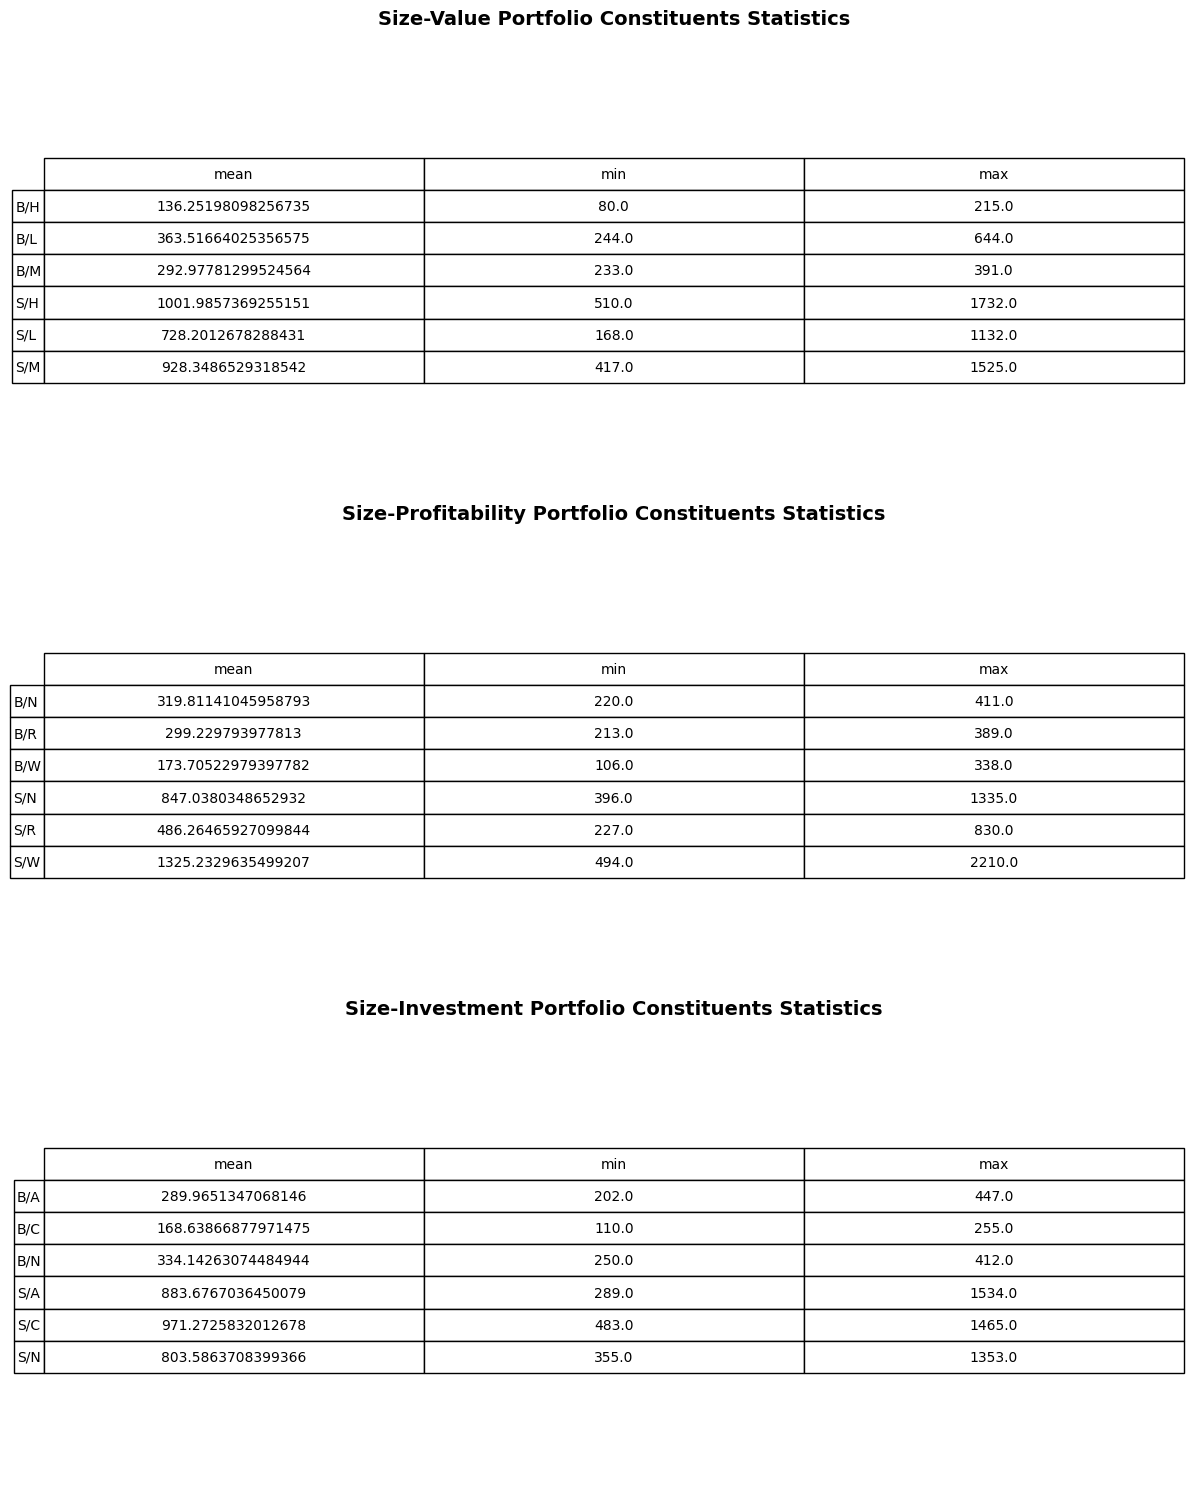

=== Size-Value Portfolio Constituents ===



=== Size-Profitability Portfolio Constituents ===



=== Size-Investment Portfolio Constituents ===


In [ ]:
# Count constituents for each factor-sorting portfolio
# Size–Value portfolios (used in SMB_size, HML)
counts_size_value = (
    stocks1970to2024
    .groupby(['date', 'size_portfolio', 'value_portfolio'])
    .permno.nunique()
    .reset_index(name='n_constituents')
)

# Size–Robust portfolios (used in SMB_robust, RMW)
counts_size_robust = (
    stocks1970to2024
    .groupby(['date', 'size_portfolio', 'robustness_portfolio'])
    .permno.nunique()
    .reset_index(name='n_constituents')
)

# Size–Investment portfolios (used in SMB_investment, CMA)
counts_size_investment = (
    stocks1970to2024
    .groupby(['date', 'size_portfolio', 'investment_portfolio'])
    .permno.nunique()
    .reset_index(name='n_constituents')
)

# Descriptive statistics over the sample period
summary_size_value = counts_size_value.groupby(['size_portfolio', 'value_portfolio'])['n_constituents'].describe()[['mean', 'min', 'max']]
summary_size_robust = counts_size_robust.groupby(['size_portfolio', 'robustness_portfolio'])['n_constituents'].describe()[['mean', 'min', 'max']]
summary_size_investment = counts_size_investment.groupby(['size_portfolio', 'investment_portfolio'])['n_constituents'].describe()[['mean', 'min', 'max']]
# Create styled tables
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Table 1: Size-Value
ax1 = axes[0]
ax1.axis('tight')
ax1.axis('off')
table1 = ax1.table(cellText=summary_size_value.values,
                   rowLabels=[f"{idx[0]}/{idx[1]}" for idx in summary_size_value.index],
                   colLabels=summary_size_value.columns,
                   cellLoc='center',
                   loc='center')
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1.2, 1.5)
ax1.set_title('Size-Value Portfolio Constituents Statistics', fontsize=14, fontweight='bold', pad=20)

# Table 2: Size-Profitability
ax2 = axes[1]
ax2.axis('tight')
ax2.axis('off')
table2 = ax2.table(cellText=summary_size_robust.values,
                   rowLabels=[f"{idx[0]}/{idx[1]}" for idx in summary_size_robust.index],
                   colLabels=summary_size_robust.columns,
                   cellLoc='center',
                   loc='center')
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1.2, 1.5)
ax2.set_title('Size-Profitability Portfolio Constituents Statistics', fontsize=14, fontweight='bold', pad=20)

# Table 3: Size-Investment
ax3 = axes[2]
ax3.axis('tight')
ax3.axis('off')
table3 = ax3.table(cellText=summary_size_investment.values,
                   rowLabels=[f"{idx[0]}/{idx[1]}" for idx in summary_size_investment.index],
                   colLabels=summary_size_investment.columns,
                   cellLoc='center',
                   loc='center')
table3.auto_set_font_size(False)
table3.set_fontsize(10)
table3.scale(1.2, 1.5)
ax3.set_title('Size-Investment Portfolio Constituents Statistics', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Alternative: Display as formatted DataFrames
print("=== Size-Value Portfolio Constituents ===")
display(summary_size_value.style.format(precision=1))

print("\n=== Size-Profitability Portfolio Constituents ===")
display(summary_size_robust.style.format(precision=1))

print("\n=== Size-Investment Portfolio Constituents ===")
display(summary_size_investment.style.format(precision=1))



CODE BLOCK 8
- importing the fama french 5 factors results from Ken French's website https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html#Research (5 Factors 2x3) Monthly
- keeping only the relevant factors from the study
- correctin the date format coming from FF5 study so that it matches the other dataframe
- left merging the two dataframe to create a dataframe that contains only the date, and both my factors and ff_factors (join made on month and year because we are testing monthly observations)
-

In [ ]:
# Comparing with Factors from Ken French's study
file = filePath + '/F-F_Research_Data_5_Factors_2x3.csv'

factorsFF = pd.read_csv(file)

#changing column names
factorsFF.to_sql('factorsFF', conn, if_exists = 'replace')
query = '''
          SELECT Date as date, [Mkt-RF] as mkt_ff, SMB as smb_ff, HML as hml_ff, RMW as rmw_ff, CMA as cma_ff
          FROM factorsFF
'''

factorsFF = pd.read_sql(query, conn)
print(factors)

#correcting the type of variables for each factor
factorsFF['mkt_ff'] = pd.to_numeric(factorsFF['mkt_ff'], errors='coerce')
factorsFF['smb_ff'] = pd.to_numeric(factorsFF['smb_ff'], errors='coerce')
factorsFF['hml_ff'] = pd.to_numeric(factorsFF['hml_ff'], errors='coerce')
factorsFF['rmw_ff'] = pd.to_numeric(factorsFF['rmw_ff'], errors='coerce')
factorsFF['cma_ff'] = pd.to_numeric(factorsFF['cma_ff'], errors='coerce')

# adding the 'month' column to the 'factors' dataframe and factorsFF to prepare for later join
factors['date'] = pd.to_datetime(factors['date'])
factors['month'] = factors['date'].dt.month
factorsFF['month'] = factorsFF['date'].astype(str).str[-2:].astype(int)

#adding year column to factors and factorsFF dataframes for later join
factors['year'] = factors['date'].dt.year
factorsFF['year'] = factorsFF['date'].astype(str).str[:4].astype(int) #take the 4 digits of the year

#joining FF results into factors
factors.to_sql('factors', conn, if_exists = 'replace')
factorsFF.to_sql('factorsFF', conn, if_exists = 'replace')
query = '''
          SELECT DISTINCT factors.date, factors.mkt/ 100 as mkt, factors.smb/100 as smb, factors.hml/100 as hml , factors.rmw/100 as rmw, factors.cma/100 as cma,
          factorsFF.mkt_ff/100 as mkt_ff, factorsFF.smb_ff/100 as smb_ff, factorsFF.hml_ff/100 as hml_ff, factorsFF.rmw_ff/100 as rmw_ff, factorsFF.cma_ff/100 as cma_ff
          FROM factors
          LEFT JOIN factorsFF
          ON factors.month = factorsFF.month
          AND factors.year = factorsFF.year
'''

factors = pd.read_sql(query, conn)
print(factors)



          date       mkt       smb       hml       rmw       cma
0   1972-06-30 -2.015270 -0.912671 -1.301528  1.553994 -1.412971
1   1972-07-31 -0.524269 -2.607781  0.535953  1.703352 -1.067236
2   1972-08-31  3.391814 -3.467904  4.627901 -2.404065  3.507634
3   1972-09-29 -1.012689 -1.941463  0.425525  1.903125 -1.958901
4   1972-10-31  0.417582 -2.379735  1.148198 -0.225252  0.346805
..         ...       ...       ...       ...       ...       ...
625 2024-07-31  1.118772  8.887540  5.627930  0.576368  0.074249
626 2024-08-30  1.516523 -3.887563 -0.508282  0.874237  0.744610
627 2024-09-30  1.695496 -1.124715 -1.984230 -0.419917  0.251660
628 2024-10-31 -1.079248 -1.141990  0.962336 -1.455002  1.166340
629 2024-11-29  6.139050  5.320231 -0.870041 -2.140467 -2.351901

[630 rows x 6 columns]
                    date       mkt       smb       hml       rmw       cma  \
0    1972-06-30 00:00:00 -0.020153 -0.009127 -0.013015  0.015540 -0.014130   
1    1972-07-31 00:00:00 -0.005243 -0.02

In [ ]:

#CHECK FOR SIZE EFFECT RELEVANCE IN JANUARY
#If January = Non-January: You'd expect differences close to 0%
#You observed: 1.24% difference
#P-value = 0.0044: This means "IF there's no January effect, there's only 0.44% chance of seeing 1.24%+ difference"
#Conclusion: Since 1.24% DID happen, and it's so unlikely under H₀, probably H₀ is wrong
from scipy import stats
factorscopy = factors.copy()

factorscopy['date'] = pd.to_datetime(factorscopy['date'])

# Extract month from date
factorscopy['month'] = factorscopy['date'].dt.month
factorscopy['year'] = factorscopy['date'].dt.year

    # ============================================================================
    # APPROACH 1: Monthly Mean Comparison
    # ============================================================================

print("="*60)
print("APPROACH 1: MONTHLY MEAN COMPARISON")
print("="*60)

# Separate January and non-January observations for both SMB versions
jan_smb = factorscopy[factorscopy['month'] == 1]['smb']
non_jan_smb = factorscopy[factorscopy['month'] != 1]['smb']

jan_smb_ff = factorscopy[factorscopy['month'] == 1]['smb_ff']
non_jan_smb_ff = factorscopy[factorscopy['month'] != 1]['smb_ff']

# Calculate means and standard deviations
jan_mean_smb = jan_smb.mean()
non_jan_mean_smb = non_jan_smb.mean()
jan_std_smb = jan_smb.std()
non_jan_std_smb = non_jan_smb.std()

jan_mean_smb_ff = jan_smb_ff.mean()
non_jan_mean_smb_ff = non_jan_smb_ff.mean()
jan_std_smb_ff = jan_smb_ff.std()
non_jan_std_smb_ff = non_jan_smb_ff.std()

    # Perform t-tests
t_stat_smb, p_value_smb = stats.ttest_ind(jan_smb, non_jan_smb)
t_stat_smb_ff, p_value_smb_ff = stats.ttest_ind(jan_smb_ff, non_jan_smb_ff)

    # Display results for your SMB
print("\nYOUR SMB FACTOR:")
print(f"January mean: {jan_mean_smb:.4f} ({jan_smb.count()} observations)")
print(f"Non-January mean: {non_jan_mean_smb:.4f} ({non_jan_smb.count()} observations)")
print(f"Difference: {jan_mean_smb - non_jan_mean_smb:.4f}")
print(f"January std: {jan_std_smb:.4f}")
print(f"Non-January std: {non_jan_std_smb:.4f}")
print(f"T-statistic: {t_stat_smb:.4f}")
print(f"P-value: {p_value_smb:.4f}")
print(f"Significant at 5%: {'Yes' if p_value_smb < 0.05 else 'No'}")

    # Display results for Fama-French SMB
print("\nFAMA-FRENCH SMB FACTOR:")
print(f"January mean: {jan_mean_smb_ff:.4f} ({jan_smb_ff.count()} observations)")
print(f"Non-January mean: {non_jan_mean_smb_ff:.4f} ({non_jan_smb_ff.count()} observations)")
print(f"Difference: {jan_mean_smb_ff - non_jan_mean_smb_ff:.4f}")
print(f"January std: {jan_std_smb_ff:.4f}")
print(f"Non-January std: {non_jan_std_smb_ff:.4f}")
print(f"T-statistic: {t_stat_smb_ff:.4f}")
print(f"P-value: {p_value_smb_ff:.4f}")
print(f"Significant at 5%: {'Yes' if p_value_smb_ff < 0.05 else 'No'}")


APPROACH 1: MONTHLY MEAN COMPARISON

YOUR SMB FACTOR:
January mean: 0.0133 (52 observations)
Non-January mean: 0.0009 (578 observations)
Difference: 0.0124
January std: 0.0410
Non-January std: 0.0290
T-statistic: 2.8533
P-value: 0.0045
Significant at 5%: Yes

FAMA-FRENCH SMB FACTOR:
January mean: 0.0113 (52 observations)
Non-January mean: 0.0005 (578 observations)
Difference: 0.0109
January std: 0.0385
Non-January std: 0.0292
T-statistic: 2.4898
P-value: 0.0130
Significant at 5%: Yes


In [ ]:
print("\n" + "="*60)
print("APPROACH 3: JANUARY CONTRIBUTION ANALYSIS")
print("="*60)

 # Calculate annual returns and January contributions
annual_analysis = []

for year in factorscopy['year'].unique():
  year_data = factorscopy[factorscopy['year'] == year]

  annual_smb = year_data['smb'].sum()
  annual_smb_ff = year_data['smb_ff'].sum()
  jan_data = year_data[year_data['month'] == 1]
  if len(jan_data) == 1:
    jan_smb = jan_data['smb'].iloc[0]
    jan_smb_ff = jan_data['smb_ff'].iloc[0]
    jan_contrib_smb = (jan_smb / annual_smb * 100)
    jan_contrib_smb_ff = (jan_smb_ff / annual_smb_ff * 100)
    annual_analysis.append({
                'year': year,
                'annual_smb': annual_smb,
                'annual_smb_ff': annual_smb_ff,
                'jan_smb': jan_smb,
                'jan_smb_ff': jan_smb_ff,
                'jan_contrib_smb': jan_contrib_smb,
                'jan_contrib_smb_ff': jan_contrib_smb_ff
            })

annual_df = pd.DataFrame(annual_analysis)

    # Calculate summary statistics
avg_jan_contrib_smb = annual_df['jan_contrib_smb'].mean()
avg_jan_contrib_smb_ff = annual_df['jan_contrib_smb_ff'].mean()

    # Expected contribution if returns were evenly distributed
expected_contrib = 100/12  # 8.33%

print("\nJANUARY CONTRIBUTION TO ANNUAL RETURNS:")
print(f"Expected if evenly distributed: {expected_contrib:.2f}%")
print(f"\nYour SMB - Average January contribution: {avg_jan_contrib_smb:.2f}%")
print(f"Your SMB - Excess over expected: {avg_jan_contrib_smb - expected_contrib:.2f}%")
print(f"\nFama-French SMB - Average January contribution: {avg_jan_contrib_smb_ff:.2f}%")
print(f"Fama-French SMB - Excess over expected: {avg_jan_contrib_smb_ff - expected_contrib:.2f}%")

    # Test if January contribution is significantly different from 8.33%
t_stat_contrib_smb, p_val_contrib_smb = stats.ttest_1samp(
  annual_df['jan_contrib_smb'].dropna(), expected_contrib
    )
t_stat_contrib_smb_ff, p_val_contrib_smb_ff = stats.ttest_1samp(
        annual_df['jan_contrib_smb_ff'].dropna(), expected_contrib
    )

print(f"\nYour SMB - T-test vs 8.33%: t={t_stat_contrib_smb:.4f}, p={p_val_contrib_smb:.4f}")
print(f"Fama-French SMB - T-test vs 8.33%: t={t_stat_contrib_smb_ff:.4f}, p={p_val_contrib_smb_ff:.4f}")


APPROACH 3: JANUARY CONTRIBUTION ANALYSIS

JANUARY CONTRIBUTION TO ANNUAL RETURNS:
Expected if evenly distributed: 8.33%

Your SMB - Average January contribution: 23.81%
Your SMB - Excess over expected: 15.48%

Fama-French SMB - Average January contribution: 31.47%
Fama-French SMB - Excess over expected: 23.13%

Your SMB - T-test vs 8.33%: t=0.7676, p=0.4463
Fama-French SMB - T-test vs 8.33%: t=0.3953, p=0.6943



APPROACH 3: JANUARY CONTRIBUTION ANALYSIS

JANUARY CONTRIBUTION TO ANNUAL RETURNS:
Expected if evenly distributed: 8.33%

Your SMB - Average January contribution: 23.81%
Your SMB - Excess over expected: 15.48%

Fama-French SMB - Average January contribution: 31.47%
Fama-French SMB - Excess over expected: 23.13%

Your SMB - T-test vs 8.33%: t=0.7676, p=0.4463
Fama-French SMB - T-test vs 8.33%: t=0.3953, p=0.6943

FILTERING DATA FOR VISUALIZATION
Before filtering:
Total years: 52
SMB contribution range: -766.7% to 352.0%
FF contribution range: -1553.8% to 2120.4%

After filtering:
Keeping 41 of 52 years
Excluded 11 extreme years
SMB contribution range: -43.7% to 100.0%
FF contribution range: -66.2% to 89.5%


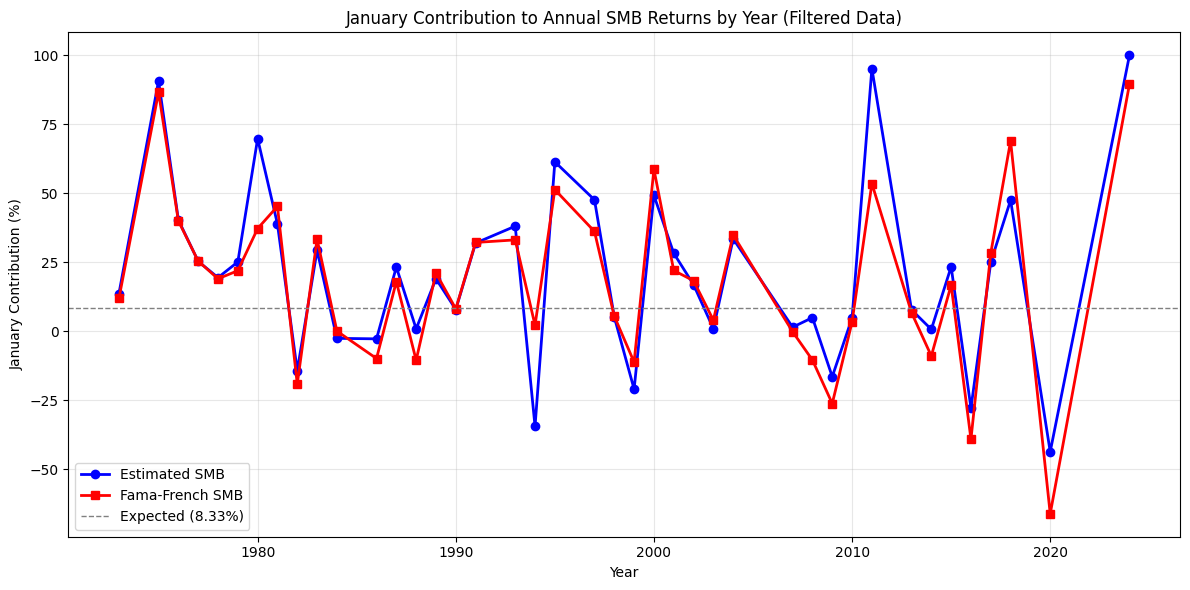


FILTERED DATA SUMMARY:
Average January contribution (filtered data):
  Your SMB: 21.0%
  Fama-French SMB: 17.8%
  Expected: 8.3%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

print("\n" + "="*60)
print("APPROACH 3: JANUARY CONTRIBUTION ANALYSIS")
print("="*60)

# Calculate annual returns and January contributions
annual_analysis = []

for year in factorscopy['year'].unique():
    year_data = factorscopy[factorscopy['year'] == year]

    annual_smb = year_data['smb'].sum()
    annual_smb_ff = year_data['smb_ff'].sum()
    jan_data = year_data[year_data['month'] == 1]

    if len(jan_data) == 1:
        jan_smb = jan_data['smb'].iloc[0]
        jan_smb_ff = jan_data['smb_ff'].iloc[0]
        jan_contrib_smb = (jan_smb / annual_smb * 100)
        jan_contrib_smb_ff = (jan_smb_ff / annual_smb_ff * 100)
        annual_analysis.append({
            'year': year,
            'annual_smb': annual_smb,
            'annual_smb_ff': annual_smb_ff,
            'jan_smb': jan_smb,
            'jan_smb_ff': jan_smb_ff,
            'jan_contrib_smb': jan_contrib_smb,
            'jan_contrib_smb_ff': jan_contrib_smb_ff
        })

annual_df = pd.DataFrame(annual_analysis)

# Calculate summary statistics BEFORE filtering
avg_jan_contrib_smb = annual_df['jan_contrib_smb'].mean()
avg_jan_contrib_smb_ff = annual_df['jan_contrib_smb_ff'].mean()
expected_contrib = 100/12  # 8.33%

print("\nJANUARY CONTRIBUTION TO ANNUAL RETURNS:")
print(f"Expected if evenly distributed: {expected_contrib:.2f}%")
print(f"\nYour SMB - Average January contribution: {avg_jan_contrib_smb:.2f}%")
print(f"Your SMB - Excess over expected: {avg_jan_contrib_smb - expected_contrib:.2f}%")
print(f"\nFama-French SMB - Average January contribution: {avg_jan_contrib_smb_ff:.2f}%")
print(f"Fama-French SMB - Excess over expected: {avg_jan_contrib_smb_ff - expected_contrib:.2f}%")

# Test if January contribution is significantly different from 8.33%
t_stat_contrib_smb, p_val_contrib_smb = stats.ttest_1samp(
    annual_df['jan_contrib_smb'].dropna(), expected_contrib
)
t_stat_contrib_smb_ff, p_val_contrib_smb_ff = stats.ttest_1samp(
    annual_df['jan_contrib_smb_ff'].dropna(), expected_contrib
)

print(f"\nYour SMB - T-test vs 8.33%: t={t_stat_contrib_smb:.4f}, p={p_val_contrib_smb:.4f}")
print(f"Fama-French SMB - T-test vs 8.33%: t={t_stat_contrib_smb_ff:.4f}, p={p_val_contrib_smb_ff:.4f}")

# NOW FILTER OUT EXTREME VALUES for graphing
print(f"\n" + "="*60)
print("FILTERING DATA FOR VISUALIZATION")
print("="*60)

print("Before filtering:")
print(f"Total years: {len(annual_df)}")
print(f"SMB contribution range: {annual_df['jan_contrib_smb'].min():.1f}% to {annual_df['jan_contrib_smb'].max():.1f}%")
print(f"FF contribution range: {annual_df['jan_contrib_smb_ff'].min():.1f}% to {annual_df['jan_contrib_smb_ff'].max():.1f}%")

# Filter out years where January contribution > 100% (absolute value)
annual_df_filtered = annual_df[
    (abs(annual_df['jan_contrib_smb']) <= 100) &
    (abs(annual_df['jan_contrib_smb_ff']) <= 100)
].copy()

print(f"\nAfter filtering:")
print(f"Keeping {len(annual_df_filtered)} of {len(annual_df)} years")
print(f"Excluded {len(annual_df) - len(annual_df_filtered)} extreme years")
if len(annual_df_filtered) > 0:
    print(f"SMB contribution range: {annual_df_filtered['jan_contrib_smb'].min():.1f}% to {annual_df_filtered['jan_contrib_smb'].max():.1f}%")
    print(f"FF contribution range: {annual_df_filtered['jan_contrib_smb_ff'].min():.1f}% to {annual_df_filtered['jan_contrib_smb_ff'].max():.1f}%")

# CREATE GRAPH with filtered data
if len(annual_df_filtered) > 0:
    # Sort by year for plotting
    annual_df_sorted = annual_df_filtered.sort_values('year')

    # Create the plot
    plt.figure(figsize=(12, 6))

    # Plot both SMB series
    plt.plot(annual_df_sorted['year'], annual_df_sorted['jan_contrib_smb'],
             marker='o', linewidth=2, label='Estimated SMB', color='blue')
    plt.plot(annual_df_sorted['year'], annual_df_sorted['jan_contrib_smb_ff'],
             marker='s', linewidth=2, label='Fama-French SMB', color='red')

    # Add expected contribution line
    plt.axhline(y=8.33, color='gray', linestyle='--', linewidth=1,
                label='Expected (8.33%)')

    # Formatting
    plt.xlabel('Year')
    plt.ylabel('January Contribution (%)')
    plt.title('January Contribution to Annual SMB Returns by Year (Filtered Data)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print filtered summary info
    filtered_avg_smb = annual_df_sorted['jan_contrib_smb'].mean()
    filtered_avg_ff = annual_df_sorted['jan_contrib_smb_ff'].mean()

    print(f"\nFILTERED DATA SUMMARY:")
    print(f"Average January contribution (filtered data):")
    print(f"  Your SMB: {filtered_avg_smb:.1f}%")
    print(f"  Fama-French SMB: {filtered_avg_ff:.1f}%")
    print(f"  Expected: 8.3%")
else:
    print("No data remaining after filtering!")

CODE BLOCK 9
- to compare the results we can test the correlation between the factors (if they are built correctly, we should see very high correltation between my factors and ff_factors)
- Measures of comparison:
  - percentiles:
  - Kolmorogorov-Smirnov test: essentially it compares two CDFs of two datasets. KS stat takes value 0 to 1 where 0 would be identical CDFs and 1 completely different with no overlap at all. So setting H_0 as having the two datasets coming from the same distribution, and the alternative h1 as the sample coming from different distribution. The objective in this case would be to accept the null hypothesis, meaning a high p-value and a low test statistic. If we set alpha = 0.05, meaning a confidence level of 95%, we would need a p-value > 0.05 to fail to reject the null. (high p-value = weak evidence against h0)  
  - Pearson correlation: normal correlation between my factors and ff_factors, I included method='pearson' because before it was giving me some problem even though the normal correlation should be pearson
  - time series graph to visualize how well my factors track the ff_factors

In [ ]:
 #Comparing the results from my study to FF
print(factors.describe(percentiles = [0.1, 0.25, 0.5, 0.75, 0.9]))

#kolmogorov-smirov test to see if data has statistically significant differences
#mkt
ks_mkt = ks_2samp(factors['mkt'], factors['mkt_ff'])
#smb
ks_smb = ks_2samp(factors['smb'], factors['smb_ff'])
#hml
ks_hml = ks_2samp(factors['hml'], factors['hml_ff'])
#rmw
ks_rmw = ks_2samp(factors['rmw'], factors['rmw_ff'])
#cma
ks_cma = ks_2samp(factors['cma'], factors['cma_ff'])

print("KS Test Results:")
print(f"MKT: statistic={ks_mkt.statistic:.4f}, p-value={ks_mkt.pvalue:.4f}")
print(f"SMB: statistic={ks_smb.statistic:.4f}, p-value={ks_smb.pvalue:.4f}")
print(f"HML: statistic={ks_hml.statistic:.4f}, p-value={ks_hml.pvalue:.4f}")
print(f"RMW: statistic={ks_rmw.statistic:.4f}, p-value={ks_rmw.pvalue:.4f}")
print(f"CMA: statistic={ks_cma.statistic:.4f}, p-value={ks_cma.pvalue:.4f}")



#computing the correlation between the variables
correlations_matrix = {
    'mkt_corr': (factors['mkt'].corr(factors['mkt_ff'], method = 'pearson')),
    'smb_corr': (factors['smb'].corr(factors['smb_ff'], method = 'pearson')),
    'hml_corr': (factors['hml'].corr(factors['hml_ff'], method = 'pearson')),
    'rmw_corr': (factors['rmw'].corr(factors['rmw_ff'], method = 'pearson')),
    'cma_corr': (factors['cma'].corr(factors['cma_ff'], method = 'pearson'))
}
factor_names = ['mkt', 'smb', 'hml', 'rmw', 'cma']

# Create difference columns
for factor in factor_names:
    factors[f'{factor}_diff'] = factors[factor] - factors[f'{factor}_ff']

# Get descriptive statistics for the differences
diff_columns = [f'{factor}_diff' for factor in factor_names]
print("Descriptive Statistics for Factor Differences (My Factor - FF Factor):")
print(factors[diff_columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))


              mkt         smb         hml         rmw         cma      mkt_ff  \
count  630.000000  630.000000  630.000000  630.000000  630.000000  630.000000   
mean     0.007135    0.001921    0.002373    0.002097    0.002722    0.006216   
std      0.046249    0.030296    0.031356    0.021320    0.018797    0.045894   
min     -0.224727   -0.114078   -0.151746   -0.118330   -0.058203   -0.231900   
10%     -0.047410   -0.033217   -0.030401   -0.020509   -0.019329   -0.049480   
25%     -0.018826   -0.014813   -0.014407   -0.008927   -0.009646   -0.020250   
50%      0.010562    0.000478    0.001599    0.001896    0.002534    0.010400   
75%      0.036252    0.020594    0.017490    0.012775    0.014053    0.035125   
90%      0.059527    0.036674    0.037931    0.025430    0.026688    0.058430   
max      0.165731    0.149201    0.147910    0.109434    0.079183    0.161000   

           smb_ff      hml_ff      rmw_ff      cma_ff  
count  630.000000  630.000000  630.000000  630.00000

GRAPHS CODE BLOCK:
- graphs to visualize:

mkt_corr: 0.9911
smb_corr: 0.9804
hml_corr: 0.9582
rmw_corr: 0.9024
cma_corr: 0.9444


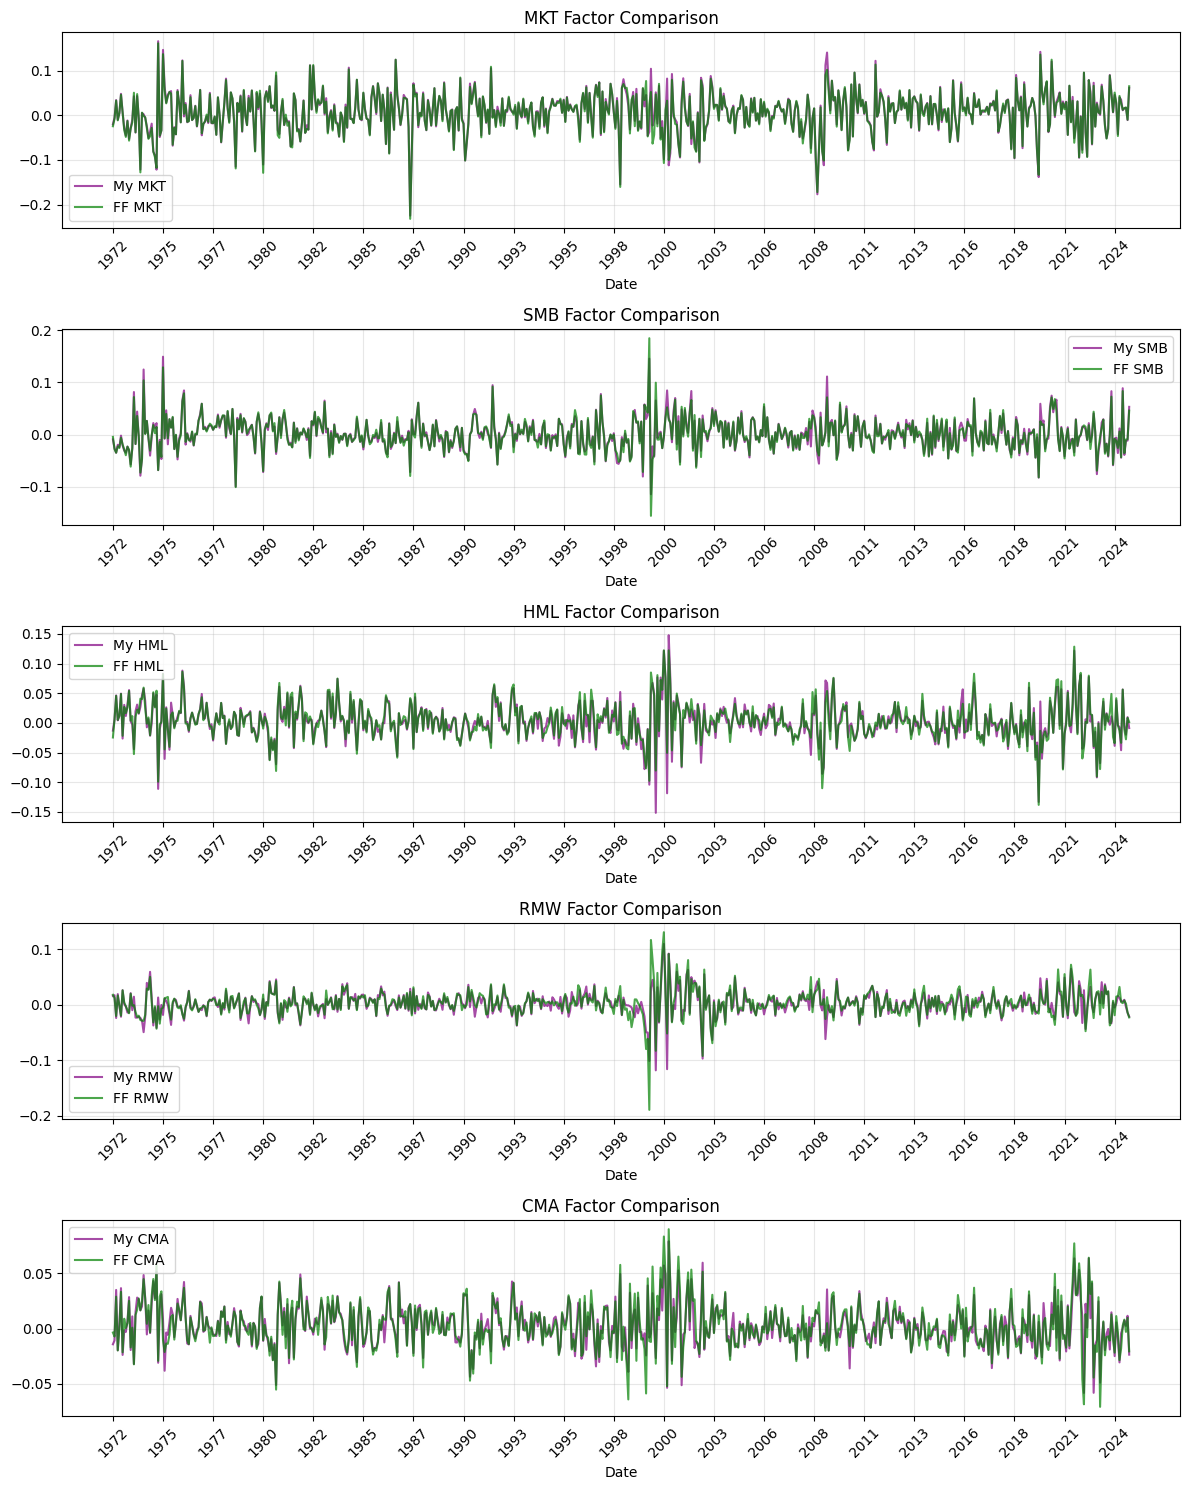

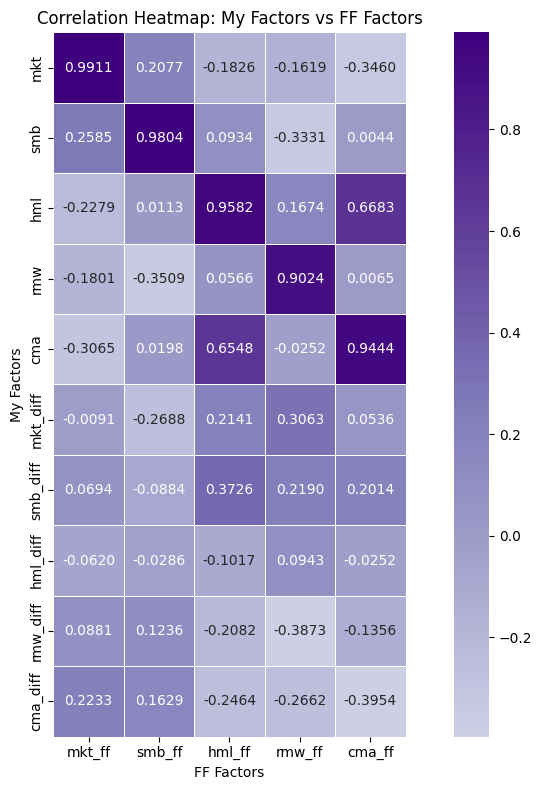

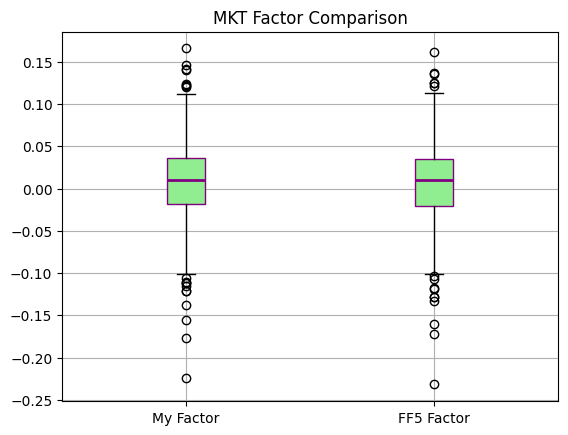

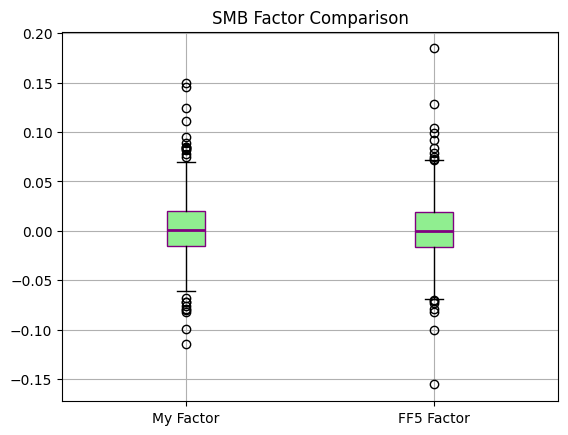

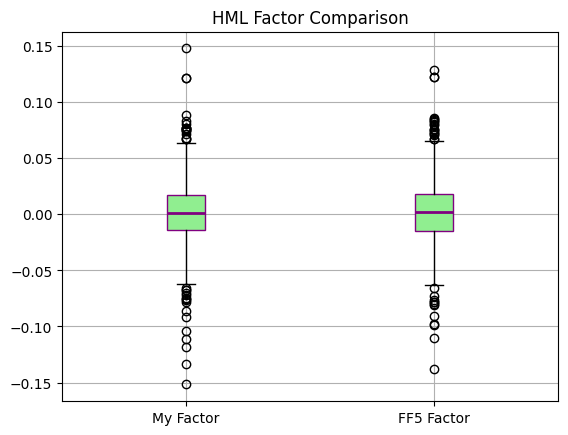

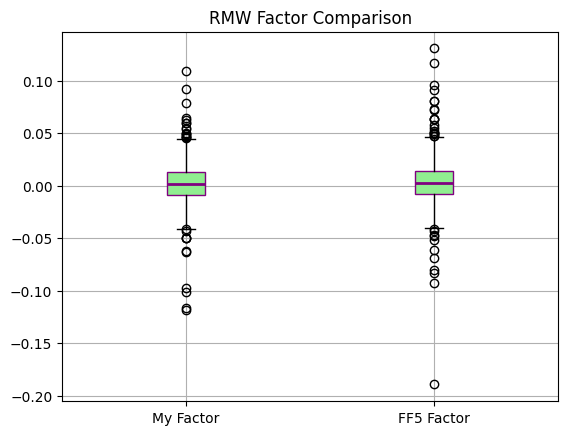

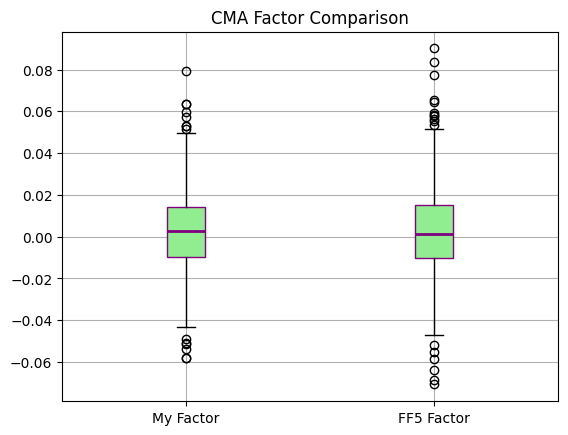

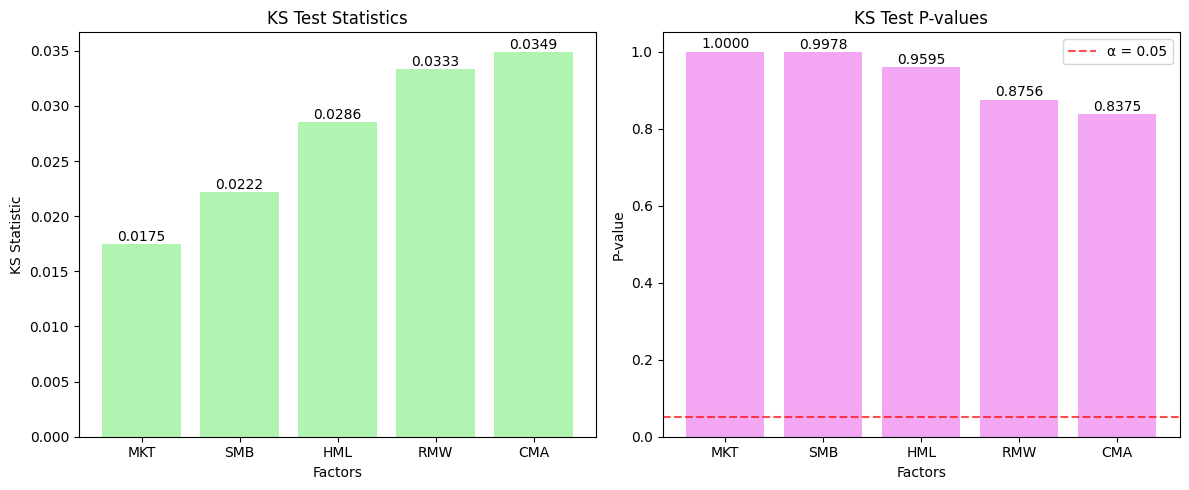

In [ ]:
for factor, corr in correlations_matrix.items():
    print(f"{factor}: {corr:.4f}")

fig, axes = plt.subplots(5, 1, figsize=(12, 15))
factors_list = ['mkt', 'smb', 'hml', 'rmw', 'cma']

# Calculate step size to get approximately 20 ticks
step = len(factors) // 20

for i, factor in enumerate(factors_list):
    axes[i].plot(factors['date'], factors[factor], label=f'My {factor.upper()}', alpha=0.7, color= 'purple')
    axes[i].plot(factors['date'], factors[f'{factor}_ff'], label=f'FF {factor.upper()}', alpha=0.7, color = 'green')
    axes[i].set_title(f'{factor.upper()} Factor Comparison')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Date')

    # Set custom ticks - show every nth date
    tick_positions = factors['date'][::step]
    tick_labels = [str(date)[:4] for date in tick_positions]  # Extract first 4 characters (year)
    axes[i].set_xticks(tick_positions)
    axes[i].set_xticklabels(tick_labels)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# plot the heatmap of correlations
my_factors = ['mkt', 'smb', 'hml', 'rmw', 'cma']
ff_factors = ['mkt_ff', 'smb_ff', 'hml_ff', 'rmw_ff', 'cma_ff']
factor_cols = factors.columns[1:]


my_factors = [col for col in factor_cols if not col.endswith('_ff')]
ff_factors = [col for col in factor_cols if col.endswith('_ff')]

full_corr = factors[factor_cols].corr()
corr_matrix = full_corr.loc[my_factors, ff_factors]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Purples', center=0,
            fmt='.4f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap: My Factors vs FF Factors')
plt.ylabel('My Factors')
plt.xlabel('FF Factors')
plt.tight_layout()
plt.show()


#plot the box plots for each factor

factor_names = ['mkt', 'smb', 'hml', 'rmw', 'cma']

# Basic one-liner for each factor
for factor in factor_names:
    pd.DataFrame({
        'My Factor': factors[factor],
        'FF5 Factor': factors[factor + '_ff']
    }).boxplot(patch_artist=True, boxprops=dict(facecolor='lightgreen', color='purple'),
               medianprops=dict(color='purple', linewidth=2),
               whiskerprops=dict(color='black'), capprops=dict(color='black'))
    plt.title(f'{factor.upper()} Factor Comparison')
    plt.show()

# visualize the KS statistics and thir p-value for each factor
factors_names = ['MKT', 'SMB', 'HML', 'RMW', 'CMA']
ks_results = [ks_mkt, ks_smb, ks_hml, ks_rmw, ks_cma]
statistics = [result.statistic for result in ks_results]
p_values = [result.pvalue for result in ks_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(factors_names, statistics, color='lightgreen', alpha=0.7)
ax1.set_title('KS Test Statistics')
ax1.set_ylabel('KS Statistic')
ax1.set_xlabel('Factors')
for bar, stat in zip(bars1, statistics):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{stat:.4f}', ha='center', va='bottom')


bars2 = ax2.bar(factors_names, p_values, color='violet', alpha=0.7)
ax2.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='α = 0.05')
ax2.set_title('KS Test P-values')
ax2.set_ylabel('P-value')
ax2.set_xlabel('Factors')
ax2.legend()

for bar, p_val in zip(bars2, p_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{p_val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
filePath = '/content/gdrive/MyDrive/Final Thesis BSc BIEF Bocconi'
file = filePath+ '/25_Portfolios_5x5.csv'
test_portfolios25_5x5 = pd.read_csv(file, sep=',')

test_portfolios25_5x5 = test_portfolios25_5x5.rename(columns = {'DATE': 'date'})
test_portfolios25_5x5['date'] = pd.to_datetime(test_portfolios25_5x5['date'], format='%Y%m%d')
cols = ['date'] + [col for col in test_portfolios25_5x5.columns if col != 'date']
test_portfolios25_5x5 = test_portfolios25_5x5[cols]
cols_to_drop = [col for col in test_portfolios25_5x5.columns if ('vwret' not in col and col != 'date')]
test_portfolios25_5x5.drop(columns=cols_to_drop, inplace=True)

import statsmodels.api as sm
copy1 = factors.copy()
copy2 = test_portfolios25_5x5.copy()
copy1['date'] = pd.to_datetime(copy1['date'])
copy2['date'] = pd.to_datetime(copy2['date'])

df_merged = pd.merge(copy2, copy1, on='date')
print('1st df: ',df_merged)

factor_cols = ['mkt', 'smb', 'hml', 'rmw', 'cma']
results = {}

rf_data['date'] = pd.to_datetime(rf_data['date'], format='%Y%m%d')
rf_data = rf_data[['date', 'rf']]  # keep only date and risk-free rate

# For portfolio/factor data
df_merged['year'] = df_merged['date'].dt.year
df_merged['month'] = df_merged['date'].dt.month

# For risk-free data
rf_data['year'] = rf_data['date'].dt.year
rf_data['month'] = rf_data['date'].dt.month
rf_data['rf'] = rf_data['rf'] / 100

df_merged = pd.merge(df_merged, rf_data[['year', 'month', 'rf']],
                     on=['year', 'month'], how='inner')


for col in copy2.columns:
    if col != 'date':
        df_merged[col] = df_merged[col] - df_merged['rf']


print('2nd df:', df_merged)




for port_return in copy2.columns:
    if port_return == 'date':
        continue  # skip the date column

    y = df_merged[port_return] # excess return if RF is risk-free rate column, otherwise just y = port return
    X = df_merged[factor_cols]
    X = sm.add_constant(X)  # add intercept

    model = sm.OLS(y, X)
    res = model.fit()
    results[port_return] = res

# 4. Example: print summary for the first portfolio
portfolios = []
alphas = []
adj_r_squared = []
alpha_tstat = []
alpha_pvalue = []
for port, res in results.items():
    portfolios.append(port)
    alphas.append(res.params['const'])  # intercept is named 'const'
    adj_r_squared.append(res.rsquared_adj)
    alpha_tstat.append(res.tvalues['const'])  # t-statistic for alpha
    alpha_pvalue.append(res.pvalues['const'])  # p-value for alpha


summary_df = pd.DataFrame({
    'Portfolio': portfolios,
    'Alpha': alphas,
    'adj_R_squared': adj_r_squared,
    'Alpha_tstat': alpha_tstat,
    'Alpha_pvalue': alpha_pvalue
})

print(summary_df)
average_r2 = summary_df['adj_R_squared'].mean()
print(f"Average adj_ R-squared: {average_r2:.4f}")
average_alpha = summary_df['Alpha'].mean()
print(f"Average Alpha: {average_alpha:.4f}")
average_alpha_tstat = summary_df['Alpha_tstat'].mean()
print(f"Average Alpha_tstat: {average_alpha_tstat:.4f}")
average_alpha_pvalue = summary_df['Alpha_pvalue'].mean()
print(f"Average Alpha_pvalue: {average_alpha_pvalue:.4f}")


1st df:            date  s1b1_vwret  s1b2_vwret  s1b3_vwret  s1b4_vwret  s1b5_vwret  \
0   1972-06-30   -0.041986   -0.042656   -0.035004   -0.030135   -0.040000   
1   1972-07-31   -0.067370   -0.050427   -0.035885   -0.035916   -0.027995   
2   1972-08-31   -0.015069   -0.023555    0.011238   -0.004669    0.022496   
3   1972-09-29   -0.048515   -0.048495   -0.044610   -0.039429   -0.041594   
4   1972-10-31   -0.035695   -0.027272   -0.024670   -0.022129   -0.019552   
..         ...         ...         ...         ...         ...         ...   
625 2024-07-31    0.121086    0.085509    0.141625    0.140338    0.145063   
626 2024-08-30   -0.016953   -0.042770   -0.026546   -0.037695   -0.021264   
627 2024-09-30    0.016419    0.010592   -0.015476   -0.012206   -0.002320   
628 2024-10-31    0.053571    0.004751   -0.007511   -0.009102    0.006604   
629 2024-11-29    0.106097    0.100156    0.095950    0.089858    0.107434   

     s2b1_vwret  s2b2_vwret  s2b3_vwret  s2b4_vwret  .

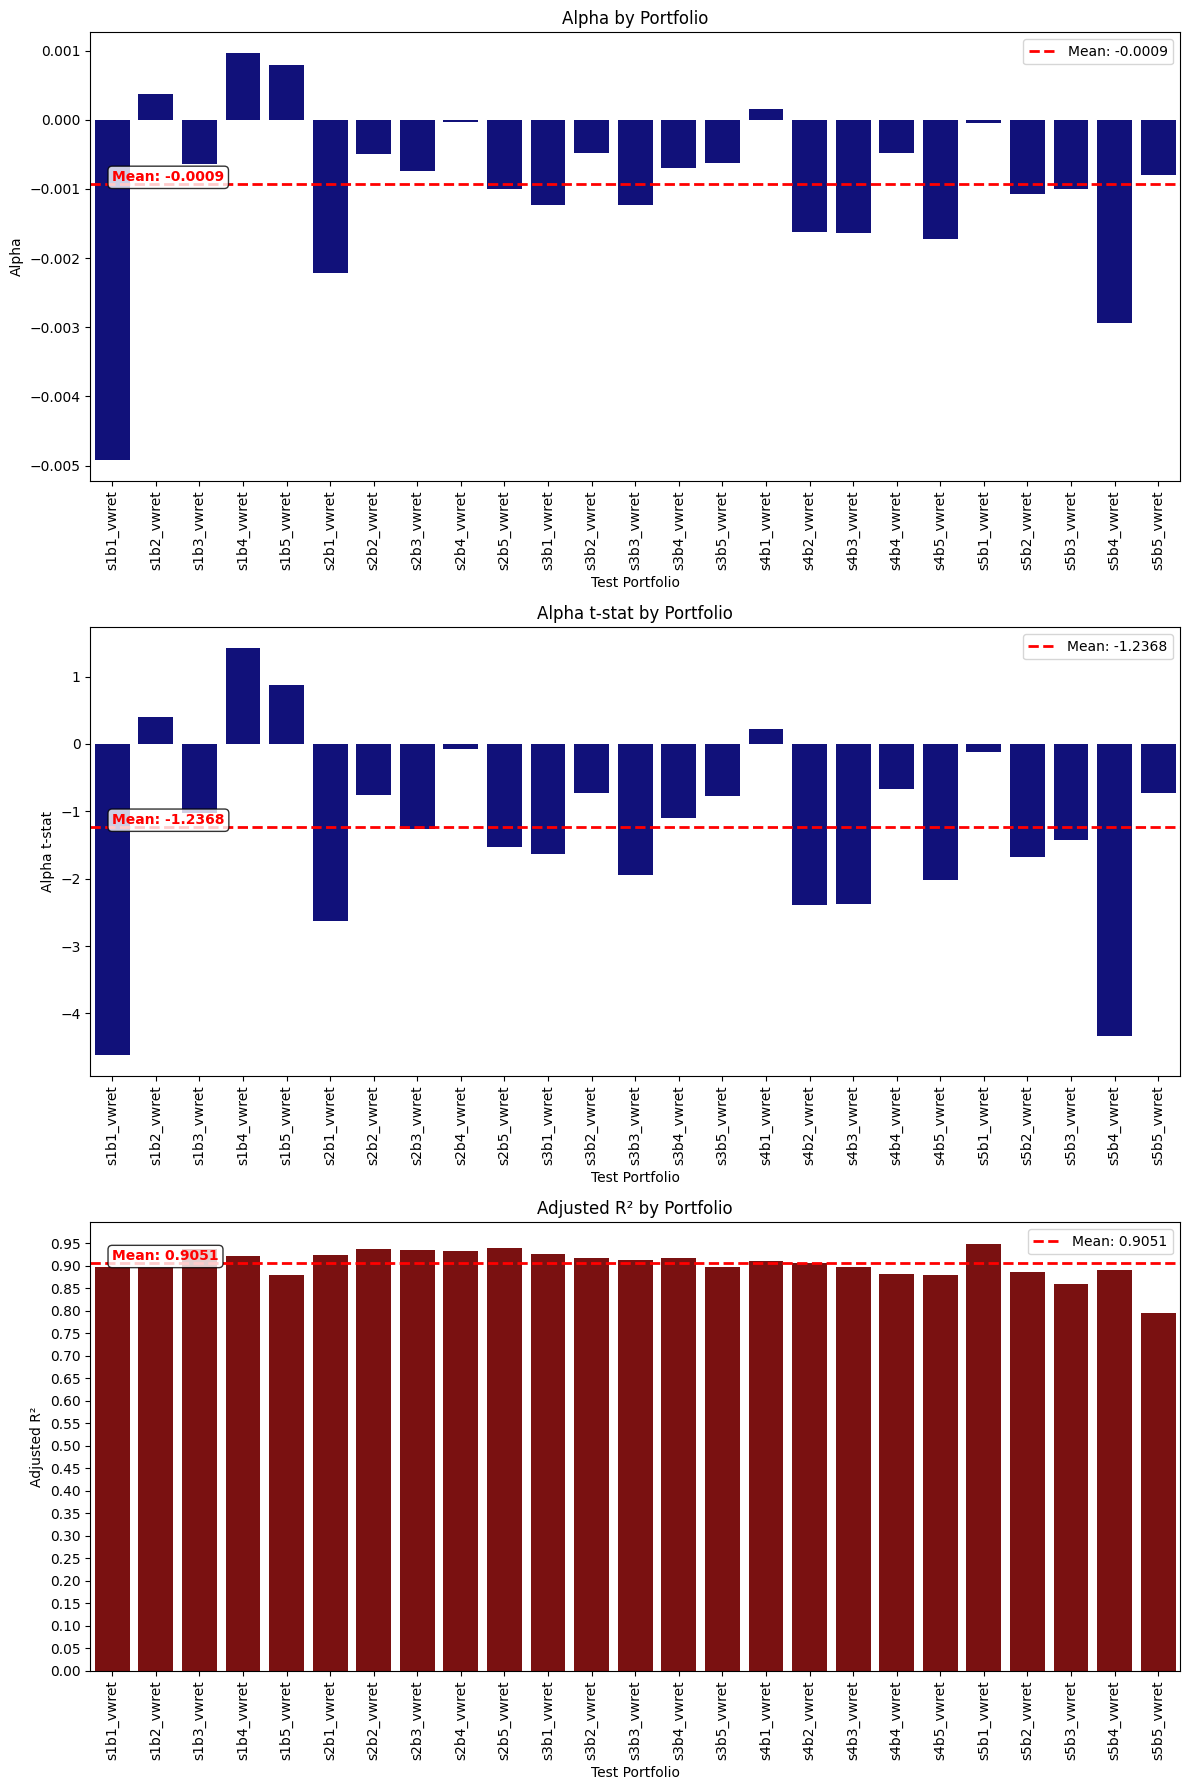

In [ ]:
plt.style.use('default')
fig, axes = plt.subplots(3, 1, figsize=(12, 18))  # 3 rows


# Sort portfolios for consistent display
summary_sorted = summary_df.sort_values('Portfolio')

##means
alpha_mean = summary_sorted['Alpha'].mean()
alpha_tstat_mean = summary_sorted['Alpha_tstat'].mean()
r2_score_mean = summary_sorted['adj_R_squared'].mean()
# --- Alpha plot ---
sns.barplot(x='Portfolio', y='Alpha', data=summary_sorted, ax=axes[0], color = 'darkblue')
axes[0].set_title('Alpha by Portfolio')
axes[0].set_ylabel('Alpha')
axes[0].set_xlabel('Test Portfolio')
axes[0].tick_params(axis='x', rotation=90)
axes[0].axhline(y=alpha_mean, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {alpha_mean:.4f}')
axes[0].legend()
axes[0].text(0.02, alpha_mean, f'Mean: {alpha_mean:.4f}',
             transform=axes[0].get_yaxis_transform(),
             verticalalignment='bottom', color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

### alpha t-stat
sns.barplot(x='Portfolio', y='Alpha_tstat', data=summary_sorted, ax=axes[1], color = 'darkblue')
axes[1].set_title('Alpha t-stat by Portfolio')
axes[1].set_ylabel('Alpha t-stat')
axes[1].set_xlabel('Test Portfolio')
axes[1].tick_params(axis='x', rotation=90)
axes[1].axhline(y=alpha_tstat_mean, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {alpha_tstat_mean:.4f}')
axes[1].legend()
axes[1].text(0.02, alpha_tstat_mean, f'Mean: {alpha_tstat_mean:.4f}',
             transform=axes[1].get_yaxis_transform(),
             verticalalignment='bottom', color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# --- R² plot ---
sns.barplot(x='Portfolio', y='adj_R_squared', data=summary_sorted, ax=axes[2], color='darkred')
axes[2].set_title('Adjusted R² by Portfolio')
axes[2].set_ylabel('Adjusted R²')
axes[2].set_xlabel('Test Portfolio')
axes[2].tick_params(axis='x', rotation=90)
axes[2].locator_params(axis='y', nbins=20)
axes[2].axhline(y=r2_score_mean, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {r2_score_mean:.4f}')
axes[2].legend()
axes[2].text(0.02, r2_score_mean, f'Mean: {r2_score_mean:.4f}',
             transform=axes[2].get_yaxis_transform(),
             verticalalignment='bottom', color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.api as sm
copy3 = factors.copy()
copy4 = test_portfolios25_5x5.copy()
copy3['date'] = pd.to_datetime(copy3['date'])
copy4['date'] = pd.to_datetime(copy4['date'])

df_merged = pd.merge(copy4, copy3, on='date')

factor_cols = ['mkt_ff', 'smb_ff', 'hml_ff', 'rmw_ff', 'cma_ff']
results = {}

for port_return in copy4.columns:
    if port_return == 'date':
        continue  # skip the date column

    y = df_merged[port_return] # excess return if RF is risk-free rate column, otherwise just y = port return
    X = df_merged[factor_cols]
    X = sm.add_constant(X)  # add intercept

    model = sm.OLS(y, X)
    res = model.fit()
    results[port_return] = res

# 4. Example: print summary for the first portfolio
portfolios = []
alphas = []
adj_r_squared = []
alpha_tstat = []
alpha_pvalue = []
for port, res in results.items():
    portfolios.append(port)
    alphas.append(res.params['const'])  # intercept is named 'const'
    adj_r_squared.append(res.rsquared_adj)
    alpha_tstat.append(res.tvalues['const'])  # t-statistic for alpha
    alpha_pvalue.append(res.pvalues['const'])  # p-value for alpha

summary_df = pd.DataFrame({
    'Portfolio': portfolios,
    'Alpha': alphas,
    'adj_R_squared': adj_r_squared,
    'Alpha_tstat': alpha_tstat,
    'Alpha_pvalue': alpha_pvalue
})

print(summary_df)
average_r2 = summary_df['adj_R_squared'].mean()
print(f"Average adj_R-squared: {average_r2:.4f}")

     Portfolio     Alpha  adj_R_squared  Alpha_tstat  Alpha_pvalue
0   s1b1_vwret  0.000272       0.918538     0.287428  7.738798e-01
1   s1b2_vwret  0.005353       0.933522     7.176885  2.032171e-12
2   s1b3_vwret  0.003796       0.947617     6.618174  7.838722e-11
3   s1b4_vwret  0.005275       0.947562     9.538751  3.188762e-20
4   s1b5_vwret  0.004985       0.896869     5.912110  5.562202e-09
5   s2b1_vwret  0.002915       0.953911     4.496888  8.222810e-06
6   s2b2_vwret  0.004070       0.951926     7.287158  9.605531e-13
7   s2b3_vwret  0.003451       0.939206     6.047097  2.540447e-09
8   s2b4_vwret  0.004136       0.943896     7.766405  3.326417e-14
9   s2b5_vwret  0.003221       0.953420     5.659490  2.315746e-08
10  s3b1_vwret  0.003670       0.947792     5.834729  8.658078e-09
11  s3b2_vwret  0.003982       0.928828     6.436001  2.446109e-10
12  s3b3_vwret  0.002730       0.915201     4.397980  1.284581e-05
13  s3b4_vwret  0.003313       0.920719     5.406602  9.156783

In [ ]:
test_portfolios25_5x5 = test_portfolios25_5x5.drop(test_portfolios25_5x5.index[-1])
print(test_portfolios25_5x5)
print(factors)

factors.to_csv('/content/gdrive/MyDrive/Final Thesis BSc BIEF Bocconi/factors.csv', index=False)
test_portfolios25_5x5.to_csv('/content/gdrive/MyDrive/Final Thesis BSc BIEF Bocconi/test_portfolios25_5x5.csv', index=False)

          date  s1b1_vwret  s1b2_vwret  s1b3_vwret  s1b4_vwret  s1b5_vwret  \
0   1972-06-30   -0.041986   -0.042656   -0.035004   -0.030135   -0.040000   
1   1972-07-31   -0.067370   -0.050427   -0.035885   -0.035916   -0.027995   
2   1972-08-31   -0.015069   -0.023555    0.011238   -0.004669    0.022496   
3   1972-09-29   -0.048515   -0.048495   -0.044610   -0.039429   -0.041594   
4   1972-10-31   -0.035695   -0.027272   -0.024670   -0.022129   -0.019552   
..         ...         ...         ...         ...         ...         ...   
625 2024-07-31    0.121086    0.085509    0.141625    0.140338    0.145063   
626 2024-08-30   -0.016953   -0.042770   -0.026546   -0.037695   -0.021264   
627 2024-09-30    0.016419    0.010592   -0.015476   -0.012206   -0.002320   
628 2024-10-31    0.053571    0.004751   -0.007511   -0.009102    0.006604   
629 2024-11-29    0.106097    0.100156    0.095950    0.089858    0.107434   

     s2b1_vwret  s2b2_vwret  s2b3_vwret  s2b4_vwret  ...  s4b1_

In [ ]:
# Create comparison dataframe

factors['date'] = pd.to_datetime(factors['date'])
test_portfolios25_5x5['date'] = pd.to_datetime(test_portfolios25_5x5['date'])
comparison_df = pd.DataFrame({
    'factors_date': factors['date'].dt.strftime('%Y-%m-%d'),
    'portfolio_date': pd.to_datetime(test_portfolios25_5x5['date']).dt.strftime('%Y-%m-%d'),
    'index': range(len(factors))
})

# Find mismatches
mismatches = comparison_df[comparison_df['factors_date'] != comparison_df['portfolio_date']]
print(f"Number of mismatches: {len(mismatches)}")
print(mismatches)

ValueError: array length 630 does not match index length 631

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression

# Debug function to check data structure
def debug_dataframes(test_portfolios, factors):
    """Debug function to examine dataframe structure"""
    print("=== DEBUGGING DATAFRAMES ===")
    print("\nTest Portfolios Info:")
    print(f"Shape: {test_portfolios.shape}")
    print(f"Index type: {type(test_portfolios.index[0]) if len(test_portfolios) > 0 else 'Empty'}")
    print(f"Columns: {list(test_portfolios.columns[:5])}...")  # Show first 5 columns
    print(f"Data types:\n{test_portfolios.dtypes}")
    print(f"First few rows:\n{test_portfolios.head()}")

    print("\nFactors Info:")
    print(f"Shape: {factors.shape}")
    print(f"Index type: {type(factors.index[0]) if len(factors) > 0 else 'Empty'}")
    print(f"Columns: {list(factors.columns)}")
    print(f"Data types:\n{factors.dtypes}")
    print(f"First few rows:\n{factors.head()}")
    print("=" * 40)

def grs_test(test_portfolios, factors, include_constant=True, debug=False):
    """
    Perform the Gibbons-Ross-Shanken (GRS) test

    Parameters:
    -----------
    test_portfolios : pd.DataFrame
        DataFrame with test portfolio returns (T x N)
    factors : pd.DataFrame
        DataFrame with factor returns (T x K)
    include_constant : bool
        Whether to include intercept in regression (default: True)

    Returns:
    --------
    dict : Dictionary containing GRS test results
    """

    if debug:
        debug_dataframes(test_portfolios, factors)

    # Ensure data alignment (preserve original dataframes)
    common_index = test_portfolios.index.intersection(factors.index)

    if len(common_index) == 0:
        raise ValueError("No common time periods between test portfolios and factors")

    # Extract aligned data - this preserves your original dataframes
    test_aligned = test_portfolios.loc[common_index]
    factors_aligned = factors.loc[common_index]

    # Only select numeric columns to avoid datetime/object columns
    test_numeric = test_aligned.select_dtypes(include=[np.number])
    factors_numeric = factors_aligned.select_dtypes(include=[np.number])

    if debug:
        print(f"After numeric filter - Test portfolios: {test_numeric.shape}")
        print(f"After numeric filter - Factors: {factors_numeric.shape}")
        print(f"Test columns: {list(test_numeric.columns)}")
        print(f"Factor columns: {list(factors_numeric.columns)}")

    # Convert to numpy arrays (this should only contain numeric data now)
    R = test_numeric.values  # T x N
    F = factors_numeric.values  # T x K

    T, N = R.shape  # T = time periods, N = test portfolios
    K = F.shape[1]  # K = number of factors

    # Add constant if requested
    if include_constant:
        F = np.column_stack([np.ones(T), F])
        K += 1

    # Step 1: Run time series regressions for each portfolio
    # R_i,t = alpha_i + beta_i * F_t + epsilon_i,t

    alphas = np.zeros(N)
    residuals = np.zeros((T, N))

    for i in range(N):
        # OLS regression: R_i = F * beta_i + alpha_i + epsilon_i
        reg = LinearRegression(fit_intercept=False)  # We handle intercept manually
        reg.fit(F, R[:, i])

        predicted = reg.predict(F)
        residuals[:, i] = R[:, i] - predicted

        # Alpha is the intercept coefficient (first coefficient if include_constant=True)
        if include_constant:
            alphas[i] = reg.coef_[0]
        else:
            # If no constant, alpha is just the mean of residuals
            alphas[i] = np.mean(residuals[:, i])

    # Step 2: Calculate covariance matrices

    # Residual covariance matrix (N x N)
    Sigma = np.cov(residuals.T)

    # Factor covariance matrix (K x K)
    if include_constant:
        # Remove constant for factor covariance calculation
        F_demean = F[:, 1:] - np.mean(F[:, 1:], axis=0)
        Omega = np.cov(F_demean.T)
    else:
        F_demean = F - np.mean(F, axis=0)
        Omega = np.cov(F_demean.T)

    # Step 3: Calculate GRS test statistic
    # GRS = (T-N-K)/N * (1 + mu_f' * Omega^-1 * mu_f)^-1 * alpha' * Sigma^-1 * alpha

    # Mean factor returns (excluding constant)
    if include_constant:
        mu_f = np.mean(F[:, 1:], axis=0)
    else:
        mu_f = np.mean(F, axis=0)

    try:
        # Calculate components
        Sigma_inv = np.linalg.inv(Sigma)
        Omega_inv = np.linalg.inv(Omega)

        # Sharpe ratio squared of factor portfolio
        sharpe_sq = mu_f.T @ Omega_inv @ mu_f

        # GRS test statistic
        numerator = (T - N - K) / N
        denominator = 1 + sharpe_sq
        quadratic_form = alphas.T @ Sigma_inv @ alphas

        grs_stat = numerator * (1/denominator) * quadratic_form

        # Degrees of freedom
        df1 = N
        df2 = T - N - K

        # P-value from F-distribution
        p_value = 1 - stats.f.cdf(grs_stat, df1, df2)

        # Individual alpha t-statistics
        alpha_se = np.sqrt(np.diag(Sigma) / T)
        alpha_t_stats = alphas / alpha_se
        alpha_p_values = 2 * (1 - stats.t.cdf(np.abs(alpha_t_stats), T - K))

        results = {
            'grs_statistic': grs_stat,
            'p_value': p_value,
            'degrees_of_freedom': (df1, df2),
            'alphas': alphas,
            'alpha_t_statistics': alpha_t_stats,
            'alpha_p_values': alpha_p_values,
            'residual_covariance_matrix': Sigma,
            'factor_covariance_matrix': Omega,
            'num_portfolios': N,
            'num_factors': K - (1 if include_constant else 0),
            'time_periods': T,
            'sharpe_ratio_squared': sharpe_sq
        }

        return results

    except np.linalg.LinAlgError as e:
        print(f"Matrix inversion failed: {e}")
        return None

def print_grs_results(results):
    """Print formatted GRS test results"""
    if results is None:
        print("GRS test failed - check for multicollinearity or insufficient data")
        return

    print("=" * 60)
    print("GIBBONS-ROSS-SHANKEN (GRS) TEST RESULTS")
    print("=" * 60)
    print(f"Test Portfolios: {results['num_portfolios']}")
    print(f"Factors: {results['num_factors']}")
    print(f"Time Periods: {results['time_periods']}")
    print(f"Degrees of Freedom: {results['degrees_of_freedom']}")
    print()
    print(f"GRS Test Statistic: {results['grs_statistic']:.4f}")
    print(f"P-value: {results['p_value']:.4f}")
    print(f"Factor Portfolio Sharpe Ratio²: {results['sharpe_ratio_squared']:.4f}")
    print()

    if results['p_value'] < 0.05:
        print("*** REJECT H0: Factor model is rejected at 5% level ***")
    else:
        print("*** FAIL TO REJECT H0: Factor model is not rejected at 5% level ***")
    print()

    print("Individual Portfolio Alphas:")
    print("-" * 50)
    for i, (alpha, t_stat, p_val) in enumerate(zip(results['alphas'],
                                                   results['alpha_t_statistics'],
                                                   results['alpha_p_values'])):
        sig_marker = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.10 else ""
        print(f"Portfolio {i+1:2d}: α = {alpha:8.4f}, t = {t_stat:7.3f}, p = {p_val:.3f} {sig_marker}")

# Example usage:
results = grs_test(test_portfolios25_5x5, factors)
print_grs_results(results)

GIBBONS-ROSS-SHANKEN (GRS) TEST RESULTS
Test Portfolios: 25
Factors: 10
Time Periods: 630
Degrees of Freedom: (25, 594)

GRS Test Statistic: 18.8244
P-value: 0.0000
Factor Portfolio Sharpe Ratio²: 0.1195

*** REJECT H0: Factor model is rejected at 5% level ***

Individual Portfolio Alphas:
--------------------------------------------------
Portfolio  1: α =  -0.0000, t =  -0.045, p = 0.964 
Portfolio  2: α =   0.0053, t =   7.512, p = 0.000 ***
Portfolio  3: α =   0.0035, t =   6.518, p = 0.000 ***
Portfolio  4: α =   0.0051, t =   9.900, p = 0.000 ***
Portfolio  5: α =   0.0047, t =   5.866, p = 0.000 ***
Portfolio  6: α =   0.0027, t =   4.521, p = 0.000 ***
Portfolio  7: α =   0.0039, t =   7.367, p = 0.000 ***
Portfolio  8: α =   0.0033, t =   6.224, p = 0.000 ***
Portfolio  9: α =   0.0039, t =   7.732, p = 0.000 ***
Portfolio 10: α =   0.0030, t =   5.676, p = 0.000 ***
Portfolio 11: α =   0.0037, t =   6.194, p = 0.000 ***
Portfolio 12: α =   0.0041, t =   7.011, p = 0.000 ***
P

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Assuming your dataframe is called 'factors' with date in first column
# Set date as index if it isn't already
if factors.columns[0] == 'date':  # or whatever your date column is named
    factors_clean = factors.set_index(factors.columns[0])
else:
    factors_clean = factors.iloc[:, 1:]  # Skip first column if it's date

# Calculate statistics for all factors at once
factor_stats = pd.DataFrame(index=factors_clean.columns)

# Mean (monthly)
factor_stats['Mean'] = factors_clean.mean()

# Standard deviation (monthly)
factor_stats['Std'] = factors_clean.std()

# T-statistic (testing if mean is significantly different from 0)
n_obs = len(factors_clean)
factor_stats['t-stat'] = factor_stats['Mean'] / (factor_stats['Std'] / np.sqrt(n_obs))

# P-values (two-tailed test)
factor_stats['p-value'] = 2 * (1 - stats.t.cdf(np.abs(factor_stats['t-stat']), df=n_obs-1))

# Annualized statistics (multiply monthly by 12 for mean, sqrt(12) for std)
factor_stats['Annual_Mean'] = factor_stats['Mean'] * 12
factor_stats['Annual_Std'] = factor_stats['Std'] * np.sqrt(12)
factor_stats['Sharpe_Ratio'] = factor_stats['Annual_Mean'] / factor_stats['Annual_Std']

print(factor_stats.round(4))

print(factors.describe(percentiles = [0.1, 0.25, 0.5, 0.75, 0.9]))


          Mean     Std  t-stat  p-value  Annual_Mean  Annual_Std  Sharpe_Ratio
mkt     0.0071  0.0463  3.8744   0.0001       0.0857      0.1603        0.5347
smb     0.0019  0.0302  1.6120   0.1075       0.0233      0.1047        0.2225
hml     0.0024  0.0313  1.8937   0.0587       0.0283      0.1084        0.2614
rmw     0.0021  0.0213  2.4745   0.0136       0.0252      0.0738        0.3415
cma     0.0027  0.0188  3.5772   0.0004       0.0321      0.0650        0.4937
mkt_ff  0.0062  0.0459  3.3994   0.0007       0.0746      0.1590        0.4692
smb_ff  0.0014  0.0302  1.1309   0.2585       0.0163      0.1047        0.1561
hml_ff  0.0030  0.0310  2.4328   0.0153       0.0360      0.1073        0.3358
rmw_ff  0.0030  0.0231  3.2538   0.0012       0.0359      0.0800        0.4491
cma_ff  0.0028  0.0204  3.4619   0.0006       0.0338      0.0707        0.4778
              mkt         smb         hml         rmw         cma      mkt_ff  \
count  630.000000  630.000000  630.000000  630.000